# Check if a bitscore for an MSA is good enough
A good MSA (similar to that from the EVmutation paper):
1. $>70\%$ of the columns covered by at least 70% of the sequences in the final alignment
2. Neff/L in 1-100, with some room for flexibility (<1 is ok after optimization)
3. If the two objectives above are conflicting, priority is given to 2
4. Additionally, for the purpose of PG2: each .m2a file should have
- more than 100 sequences
- less than 2M sequences (usually should be the case when Neff/L < 100)
- separately list the design sequences
5. Remove alignments that align to $<70\%$ of the length of the target sequence

## Next:
- run the code at the very end to rename and download weights.npy and move the output with selected bitscore to a designated folder - remove the misnamed weights, models files (without the offset index in the DMS_id)
- visualize the alignments where perc_cov went down with higher bitscores

In [1]:
import sys
from glob import glob
import numpy as np
from os.path import basename, exists
import pandas as pd
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import subprocess
from contextlib import contextmanager,redirect_stderr,redirect_stdout

# from evcouplings.align.alignment import Alignment

In [2]:
os.chdir("/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/EVCouplings")

## Approach 1: Using EVCouplings functions on O2
Aaron's instruction:
Compute the number of alignment columns that pass the minimum column coverage threshold of 0.7. Use the evcouplings package to load the alignment (similar to the [set_weights() example](https://github.com/debbiemarkslab/EVcouplings/blob/7e0076de24426ef62aa13ec7154f1b8661f0e950/evcouplings/align/alignment.py#L878)). Then use the [count() function](https://github.com/debbiemarkslab/EVcouplings/blob/75bfc9677fc9412ddb7089a9f26c7a01f65bfa12/evcouplings/align/alignment.py#L707) to count the fraction of gaps (-) at each position. Then you can count how many positions are above 0.7.

Load one of the MSAs that finished the EVCouplings run at bitscore = 0.7

Calculate the weights of each sequence in the MSA - the runtime of this step scales with O(num_seq^2)

Calculate Neff/L

In [9]:
msa_f = "output/Beltran_Lehner_2025/uniref100/A0A2R8Y422_PF00240_2/A0A2R8Y422_PF00240_2_bit_0.7_theta_0.8_colcov_0/align/A0A2R8Y422_PF00240_2_bit_0.7_theta_0.8_colcov_0.a2m"

In [8]:
with open(msa_f) as f:
    a = Alignment.from_file(f)
    gap_frac = a.count("-")
    overall_cov = (gap_frac<0.3).sum()/a.L
    print(f"the fraction of gaps of each column is {gap_frac}")
    print(f"{overall_cov} of the entire sequence is covered by at least 70% of all seqwuences in the MSA")

    a.set_weights()
    print(f"Neff/L including gaps: {a.weights.sum()/a.L}")

the fraction of gaps of each column is [0.38962621 0.1222567  0.06540067 0.04987086 0.03705388 0.03247291
 0.02896408 0.02490294 0.02011079 0.01452265 0.01237837 0.01200474
 0.00950308 0.00760246 0.00614045 0.00503582 0.0041911  0.00417486
 0.00321643 0.00246918 0.00159197 0.00118585 0.00113712 0.00107214
 0.00170568 0.00154323 0.00151075 0.0014945  0.0013483  0.00139703
 0.00196559 0.0048084  0.00493835 0.00555565 0.00529573 0.00531198
 0.00547442 0.00501957 0.00256664 0.00173817 0.0012021  0.00115337
 0.00112088 0.00092594 0.00108839 0.00087721 0.00129957 0.00094219
 0.00077974 0.00116961 0.00196559 0.00250167 0.00755373 0.00563687
 0.00479215 0.0061567  0.00664403 0.00778115 0.00872334 0.00971426
 0.01065644 0.08211634 0.01444143 0.0170893  0.0196397  0.02540652
 0.03718384 0.0743027  0.12430351 0.32266606]
0.9714285714285714 of the entire sequence is covered by at least 70% of all seqwuences in the MSA
Neff/L including gaps: 83.15845957017538


Remove gaps and calculate Neff/L

In [11]:
with open(msa_f) as f:
    a = Alignment.from_file(f)
    a2 = a.select(columns=(a.count("-") < 0.3)) # is this step necessary?
    a2.set_weights()
    neff_l = a2.weights.sum()/a2.L
    print(neff_l)

89.84169951918864


In [8]:
a2.weights.sum()/a2.L

np.float64(89.84169951918864)

**Note**: Aaron's EVE code (see Approach 2 below) calculated the Neff/L to be 84.70113975759325

Check the results of finished MSAs

In [4]:
def check_msa(msa_f, gap_frac_thresh=0.3, cov_thresh=0.8, neff_l_thresh=1):
    seq_name = msa_f.split("/")[-4]
    weights_output = msa_f.rstrip(".a2m") + "_weights"
    print(weights_output)
    with open(msa_f) as f:
        a = Alignment.from_file(f)
        overall_cov = (a.count("-") < gap_frac_thresh).sum()/a.L
    
        a.set_weights()
        # save the weights
        np.save(weights_output, a.weights)
        neff_l = a.weights.sum()/a.L

    # print(seq_name)
    # print(overall_cov)
    # print(neff_l)
    print(seq_name)
    bitscore = 0.7

    if overall_cov > cov_thresh and neff_l > neff_l_thresh:
        # print(f"{seq_name} is good")
        bitscore = 0.7
    elif overall_cov <= cov_thresh and neff_l > neff_l_thresh:
        # print(f"increase the bitscore of {seq_name}")
        bitscore = 0.9
    elif overall_cov > cov_thresh and neff_l <= neff_l_thresh:
        # print(f"reduce the bitscore of {seq_name}")
        bitscore = 0.5
    elif overall_cov <= cov_thresh and neff_l <= neff_l_thresh:
        # print(f"reduce the bitscore of {seq_name}")
        bitscore = 0.5
    return bitscore

In [22]:
bitscore = check_msa("output/Beltran_Lehner_2025/uniref100/A0A2R8Y422_PF00240_2/A0A2R8Y422_PF00240_2_bit_0.7_theta_0.8_colcov_0/align/A0A2R8Y422_PF00240_2_bit_0.7_theta_0.8_colcov_0.a2m")
print(f"suggested bitscore={bitscore}")

output/Beltran_Lehner_2025/uniref100/A0A2R8Y422_PF00240_2/A0A2R8Y422_PF00240_2_bit_0.7_theta_0.8_colcov_0/align/A0A2R8Y422_PF00240_2_bit_0.7_theta_0.8_colcov_0_weights
A0A2R8Y422_PF00240_2
suggested bitscore=0.7


In [ ]:
with open('0.7_bitscore_run_result.csv', 'w') as f_out:
    for name in glob('output/Beltran_Lehner_2025/uniref100/*/*_bit_0.7_theta_0.8_colcov_0/align/*_bit_0.7_theta_0.8_colcov_0.a2m'):
        # bitscore = check_msa(name)
        # seq_name = name.split("/")[-4]
        # f_out.write(f"{seq_name},{bitscore}\n")
        print(name)
        with open(name) as f:
            a = Alignment.from_file(f)
            print(a.matrix.shape)

output/Beltran_Lehner_2025/uniref100/A0A2R8Y422_PF00240_2/A0A2R8Y422_PF00240_2_bit_0.7_theta_0.8_colcov_0/align/A0A2R8Y422_PF00240_2_bit_0.7_theta_0.8_colcov_0.a2m
(61559, 70)
output/Beltran_Lehner_2025/uniref100/A0PJY2_PF00096_289/A0PJY2_PF00096_289_bit_0.7_theta_0.8_colcov_0/align/A0PJY2_PF00096_289_bit_0.7_theta_0.8_colcov_0.a2m


## Approach 2: Using EVE code on AWS
The above procedure is too slow, because of the large number (over 4 M) of alignments in very short sequences. Therefore, I use [Aaron's forked EVE code](https://github.com/aaronkollasch/EVE/blob/master/scripts/get_alignment_stats.py) on AWS to do the calculation instead. The finished .a2m files above are copied to `/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/EVCouplings/output/Beltran_Lehner_2025/bitscore0.7_a2m` synced to `s3://markslab-private/eve/beltran_domains/data/MSA/beltran_domains_jackhmmer_bitscore_0.7` (aws s3 sync).

To access the Marks lab EC2 instance to run EVE: ssh ubuntu@`Public_DNS_from_ec2_page`

Launch the EC2 instance from the AWS web page: alignment_stats_calc

I then generate the mapping file `beltran_domains_jackhmmer_bitscore_0.7_mapping.csv` and sync it to `s3://markslab-private/eve/beltran_domains/data/mappings/` (aw3 s3 cp) for the alignment stats calculation. Instance type: c5ad.24xlarge

Modify `/home/ubuntu/EVE/scripts/get_alignment_stats.py`
- add tier 10
- update the `s3_cp_file`
- update the `df`
- update `threshold_focus_cols_frac_gaps` to 0.3 (default)
- update `num_cpus` to 16
- enable function to take in protein_name and msa_location
- set weights of really large MSAs (with over 500k sequences) to 1, without any computation, otherwise the jobs can't finish

Run the above script under `py310` conda env

**Remember to do `sudo poweroff` to shut down the EC2 instance after finishing**

## Check the Neff/L and perc_cov calculations
Compare the output from EVE and PG1 code (git cloned from the repo)

Switch to the pg1 kernel

In [3]:
sys.path.append("/n/groups/marks/users/elain/PG2/ProteinGym")
from proteingym.utils.msa_utils import MSA_processing

Calculate weights and perc_cov

In [15]:
def get_aln_stats(protein, MSA_location, weights_location, skip_one_hot_encodings=True):
    '''
    modified from get_aln_stats on https://github.com/aaronkollasch/EVE/blob/master/scripts/get_alignment_stats.py
    remove all AWS commands
    '''
    # weights_fname = protein + '_theta_' + str(theta) + '.npy'

    msa = MSA_processing(
        MSA_location=MSA_location,
        weights_location=weights_location,
        threshold_focus_cols_frac_gaps=0.3)

    #assert msa.focus_seq_name.lstrip(">")  == protein
    num_seqs = 0
    with open(MSA_location) as f:
        for line in f:
            if line.startswith(">"):
                num_seqs += 1

    result = {
        "protein": protein,
        "num_seqs": msa.num_sequences,
        "num_seqs_unfiltered": num_seqs,
        "perc_filtered": msa.num_sequences / num_seqs,
        "n_eff": msa.Neff,
        "n_eff_l": msa.Neff / len(msa.focus_seq),
        "seq_len": len(msa.focus_seq),
        "num_cov": msa.one_hot_encoding.shape[1],
        "perc_cov": msa.one_hot_encoding.shape[1] / len(msa.focus_seq),
    }

    print(protein)
    return result

In [16]:
test_result_df = get_aln_stats("A0A2R8Y422_PF00240_2", msa_f, "./test.npy")

Proportion of sequences dropped due to fraction of gaps: 0.0%
Proportion of non-focus columns removed: 2.86%


/n/groups/marks/projects/indels_human/anon/proteingym/utils/msa_utils.py:100: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.seq_name_to_sequence[msa_df.index[seq_idx]] = msa_df.sequence[seq_idx]


Encoding sequences
One-hot encoded sequences shape:(61139, 68, 20)
Computing sequence weights
Neff = 5929.079783031528
Data Shape = (61139, 68, 20)
A0A2R8Y422_PF00240_2


In [17]:
test_result_df

{'protein': 'A0A2R8Y422_PF00240_2',
 'num_seqs': 61139,
 'num_seqs_unfiltered': 61559,
 'perc_filtered': 0.9931772770837732,
 'n_eff': 5929.079783031528,
 'n_eff_l': 84.70113975759325,
 'seq_len': 70,
 'num_cov': 68,
 'perc_cov': 0.9714285714285714}

### Conclusion: 
This is exactly the same as the EVE AWS aln_stats_calc output!

Should use AWS EVE code (faster) or PG1 code to calculate weights and all other stats

## Summary of run at bitscore 0.7
- 522 proteins in total
- 483 finished
- 32 terminated (checking now whether b/c they have over too many sequences in MSA - .a2m files are too large)
- 2 bailout (2 Rocklin sequences have no other alignment in the .a2m - normal because they are designed sequences, hard to align against natural sequences)
- 5 went OOM

**Note: the N_eff shown below isn't necessarily the correct one - for efficient computation, we set all weights to 1 for .a2m with >500k sequences**

**Note 2: all N_eff shown below is calculated on the .a2m file with minimum_column_coverage = 0, which may be different from the .a2m file with minimum_column_coverage = 0.7**

In [5]:
mapping_file = 'output/Beltran_Lehner_2025/mappings/beltran_domains_jackhmmer_bitscore_0.7_mapping.csv'
input_dir = 'output/Beltran_Lehner_2025/bitscore0.7_a2m/'
suffix = '_bit_0.7_theta_0.8_colcov_0.a2m'
with open(mapping_file, 'w') as f_out:
    f_out.write('protein_name,msa_location,theta\n')
    for name in glob(input_dir + '*.a2m'):
        protein_name = basename(name).removesuffix(suffix)
        f_out.write(f"{protein_name},{basename(name)},0.2\n")

In [6]:
aln_stats = "output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_bitscore_0.7_aln_stats.csv"
aln_stats_df = pd.read_csv(aln_stats)
aln_stats_df.head()

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov
0,A0A2R8Y422_PF0024,61139,61559,0.993177,5.929080e+03,84.701140,70,68,0.971429
1,A0PJY2_PF00096_289,4082271,4087406,0.998744,4.082271e+06,185557.772727,22,21,0.954545
2,A1X283_PF00018_155,514408,514768,0.999301,1.442098e+04,262.199550,55,49,0.890909
3,A1X283_PF0001,503000,503356,0.999293,1.443939e+04,244.735369,59,50,0.847458
4,A2RRE5_PF01846_26,4527,4543,0.996478,1.287046e+02,2.042930,63,60,0.952381


In [7]:
# only run this block once, to fix a bug from mapping file generation
mapping_df = pd.read_csv(mapping_file)
df_concat = pd.concat([mapping_df, aln_stats_df], axis=1)
aln_stats_df = df_concat.drop(['msa_location', 'theta', 'protein'], axis=1).rename(columns={'protein_name': 'protein'})
aln_stats_df

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov
0,A0A2R8Y422_PF00240_2,61139,61559,0.993177,5.929080e+03,84.701140,70,68,0.971429
1,A0PJY2_PF00096_289,4082271,4087406,0.998744,4.082271e+06,185557.772727,22,21,0.954545
2,A1X283_PF00018_155,514408,514768,0.999301,1.442098e+04,262.199550,55,49,0.890909
3,A1X283_PF00018_222,503000,503356,0.999293,1.443939e+04,244.735369,59,50,0.847458
4,A2RRE5_PF01846_267,4527,4543,0.996478,1.287046e+02,2.042930,63,60,0.952381
...,...,...,...,...,...,...,...,...,...
512,Q9Y5K6_PF14604_109,473102,473428,0.999311,1.245652e+04,204.205232,61,52,0.852459
513,Q9Y5K6_PF14604_1,510289,510619,0.999354,1.383689e+04,234.523617,59,50,0.847458
514,Q9Y618_PF00249_613,57496,57518,0.999618,1.467850e+03,25.307762,58,48,0.827586
515,Q9Y6N9_PF00595_207,123241,123337,0.999222,1.477510e+03,16.601235,89,74,0.831461


### Check the sequences with terminated runs

In [6]:
# aln_stats_df = aln_stats_df.reset_index()  # make sure indexes pair with number of rows
n_terminated = 0
n_large_seq = 0 # number of .a2m with more than 500k sequences

for index, row in aln_stats_df.iterrows():
    terminated_file = f"output/Beltran_Lehner_2025/uniref100/{row['protein']}/{row['protein']}_bit_0.7_theta_0.8_colcov_0.terminated"
    if exists(terminated_file):
        n_terminated += 1
        print(row['protein'], row['num_seqs'], row['seq_len'], row['perc_cov'], row['n_eff_l'])
        if row['num_seqs'] > 500000:
            n_large_seq += 1
print(f"\n{n_large_seq} sequences have >500k sequences in the .a2m file and among these {n_terminated} jobs were terminated")

A0PJY2_PF00096_289 4082271 22 0.9545454545454546 185557.77272727276
O14901_PF00096_395 4120396 24 0.875 171683.16666666666
O43167_PF00096_351 4287206 22 0.9545454545454546 194873.0
O60281_PF00096_808 4121885 24 0.875 171745.20833333334
O60481_PF00096_389 4214276 22 0.9545454545454546 191558.0
P08151_PF00096_363 3573799 25 0.8 142951.96
P10070_PF00096_565 3368710 25 0.8 134748.4
P10071_PF00096_608 3356392 25 0.8 134255.68
P25490_PF00096_384 4128961 24 0.875 172040.04166666666
P37275_PF00096_933 4286191 22 0.9545454545454546 194826.86363636365
P51508_PF00096_331 4063773 22 0.9545454545454546 184716.95454545456
P57071_PF00096_1085 4301151 22 0.9545454545454546 195506.86363636365
Q5F1R6_PF12171_315 3968177 25 0.84 158727.08
Q8NEA6_PF00096_414 4084613 23 0.9130434782608696 177591.86956521738
Q8NEA6_PF00096_473 4111356 24 0.875 171306.5
Q8TDD2_PF00096_325 4120979 24 0.875 171707.45833333334
Q99684_PF00096_256 3904986 23 0.8260869565217391 169782.0
Q99684_PF00096_313 4266639 22 0.954545454545

**Conclusions:**
1. All sequences are 21-25 bp
2. All have millions of sequences in the final .a2m files, while the fraction of columns covered by at least 70\% is relatively high
3. Can raise the bitscore to 0.9

### Check the sequences with finished and terminated jobs
Get a count of sequences to rerun

In [6]:
n_done = 0
n_good = 0
n_too_high = 0
n_too_low = 0
n_term = 0
n_bailout = 0

def check_msa_df(row, gap_frac_thresh=0.3, cov_thresh=0.8, neff_l_thresh=1):
    if row['perc_cov'] >= cov_thresh and row['n_eff_l'] > neff_l_thresh:
        # print(f"{seq_name} is good")
        bitscore = 0.7
    elif (row['perc_cov'] < cov_thresh and row['n_eff_l'] > neff_l_thresh):
        # print(f"increase the bitscore of {seq_name}")
        bitscore = 0.9
    elif row['n_eff_l'] <= neff_l_thresh:
        # print(f"reduce the bitscore of {seq_name}")
        bitscore = 0.5
    return bitscore

term_list = []
higher_bitscore = []
lower_bitscore = []
bailout_list = []
for index, row in aln_stats_df.iterrows():
    done_file = f"output/Beltran_Lehner_2025/uniref100/{row['protein']}/{row['protein']}_bit_0.7_theta_0.8_colcov_0.done"
    terminated_file = f"output/Beltran_Lehner_2025/uniref100/{row['protein']}/{row['protein']}_bit_0.7_theta_0.8_colcov_0.terminated"
    bail_out_file = f"output/Beltran_Lehner_2025/uniref100/{row['protein']}/{row['protein']}_bit_0.7_theta_0.8_colcov_0.bailout"

    if exists(done_file):
        n_done += 1
        bitscore = check_msa_df(row)
        if bitscore == 0.7:
            n_good += 1
        elif bitscore == 0.5:
            n_too_high += 1
            lower_bitscore.append(row['protein'])
        elif bitscore == 0.9:
            n_too_low += 1
            higher_bitscore.append(row['protein'])
    elif exists(terminated_file):
        n_term += 1
        term_list.append(row['protein'])
    elif exists(bail_out_file):
        n_bailout += 1
        bailout_list.append(row['protein'])
    else:
        print(row['protein'])

print(f"out of {n_done} sequences, \n" \
f"{n_good} sequences are good,\n" \
f"{n_too_high} sequences need a lower bitscore\n" \
f"{n_too_low} sequences need a higher bitscore")

print(f"\n{n_term} sequences were terminated, {n_bailout} sequences had bailout error")

out of 483 sequences, 
417 sequences are good,
20 sequences need a lower bitscore
46 sequences need a higher bitscore

32 sequences were terminated, 2 sequences had bailout error


## Next steps: Launch more jobs based on adjusted bitscores
1. For those with OOM (n=5) and terminated jobs: rerun at bitscore of 0.9, 1 (in total n=37)
2. For those with finished results but need a higher bitscore: rerun at bitscore of 0.8, 0.9, 1 (n=23)
3. For those with bailout: rerun at bitscore of 0.5 (n=2)
4. for those with finished results but need a lower bitscore: rerun at bitscore of 0.5, 0.6 (n=20)

125 more jobs in total - write separate sequence csv files as input for each bitscore

In [7]:
OOM_list = [
    'O43167_PF00096_435', 'P51508_PF00096_555', 'Q5VTD9_PF00096_221', 'Q9NU63_PF00096_176', 'Q9Y2G7_PF00096_411'
           ]
bitscore_9 = [*OOM_list, *term_list]
bitscore_9.extend(higher_bitscore)
print(len(bitscore_9))

bitscore_8 = higher_bitscore.copy()
print(len(bitscore_8))

bitscore_6 = lower_bitscore.copy()
print(len(bitscore_6))

bitscore_5 = [*lower_bitscore, *bailout_list]
print(len(bitscore_5))

bitscore_10 = bitscore_9.copy()
print(len(bitscore_10))

83
46
20
22
83


In [20]:
print(higher_bitscore)
print(lower_bitscore)

['O00308_PF00397_440', 'O15541_PF00642_198', 'O75400_PF00397_176', 'O95817_PF00397_11', 'P11961_PF02817_126', 'P16989_PF00313_84', 'P39940_PF00397_324', 'P40040_PF02037_1', 'P46934_PF00397_836', 'P46937_PF00397_162', 'P46937_PF00397_165', 'P46937_PF00397_226', 'P49792_PF00641_1414', 'P67809_PF00313_52', 'P82979_PF02037_3', 'Q00987_PF00641_299', 'Q14151_PF02037_27', 'Q15424_PF02037_26', 'Q5TCQ9_PF00397_287', 'Q6ZWJ1_PF00397_493', 'Q86UL8_PF00397_296', 'Q8IX12_PF02037_625', 'Q8IZQ8_PF02037_363', 'Q8IZT6_PF00612_1877', 'Q8N3X1_PF00397_593', 'Q8NEZ5_PF00646_25', 'Q969V6_PF02037_341', 'Q96J02_PF00397_428', 'Q96J02_PF00397_474', 'Q96PU5_PF00397_184', 'Q96PU5_PF00397_381', 'Q96PU5_PF00397_539', 'Q96QZ7_PF00397_294', 'Q96QZ7_PF00397_352', 'Q9BUJ2_PF02037_1', 'Q9BYW2_PF00397_2382', 'Q9GZV5_PF00397_116', 'Q9H0A6_PF00612_189', 'Q9H0M0_PF00397_343', 'Q9HAU4_PF00397_150', 'Q9NWH9_PF02037_19', 'Q9P2P5_PF00397_800', 'Q9P2R6_PF00320_502', 'Q9UIF8_PF00628_1927', 'Q9UKL0_PF00249_383', 'Q9Y2T7_PF00313_86

#### Note: 
after fixing the bug in EVE code for aln_stats_calc, we have different number of sequences to run at higher bitscore

check if all the higher bitscores have been run at bitscore=0.9

In [27]:
aws_rerun_list = []
for protein in higher_bitscore:
    m2a = f"output/Beltran_Lehner_2025/uniref100/{protein}/{protein}_bit_0.9_theta_0.8_colcov_0/align/{protein}_bit_0.9_theta_0.8_colcov_0.a2m"
    if not exists(m2a):
        print(protein)
        aws_rerun_list.append(protein)
        # !ls output/Beltran_Lehner_2025/uniref100/{protein}
        # print(aln_stats_df[aln_stats_df['protein']== protein])

O75400_PF00397_176
P39940_PF00397_324
P46937_PF00397_165
P82979_PF02037_3
Q14151_PF02037_27
Q15424_PF02037_26
Q5TCQ9_PF00397_287
Q8IX12_PF02037_625
Q8IZQ8_PF02037_363
Q969V6_PF02037_341
Q96QZ7_PF00397_294
Q9BUJ2_PF02037_1
Q9NWH9_PF02037_19
Q9P2R6_PF00320_502
Q9UIF8_PF00628_1927
Q9UKL0_PF00249_383
Q9Y2T7_PF00313_86


All only have been run at bitscore 0.7, perc_cov now drops below 80% (but not by much), but the Neff/L all look good. Rerun the 17 sequences at bitscore=0.8 and 0.9

convert the list into .csv file as input to EVCouplings pipeline

In [9]:
bitscore_7_df = pd.read_csv('input/Beltran_Lehner_2025/sequences_0.7.csv')

In [8]:
def conv_list_to_csv(lst, output_path, full_csv_df=bitscore_7_df):
    protein_name_df = pd.DataFrame(lst, columns=['UniProt_ID'])
    protein_full_df = protein_name_df.merge(bitscore_7_df, how='inner', on='UniProt_ID')
    protein_full_df.to_csv(output_path, index=False)

# conv_list_to_csv(bitscore_9, 'input/Beltran_Lehner_2025/sequences_0.9_new.csv')
# conv_list_to_csv(bitscore_8, 'input/Beltran_Lehner_2025/sequences_0.8_new.csv')
# conv_list_to_csv(bitscore_6, 'input/Beltran_Lehner_2025/sequences_0.6_new.csv')
# conv_list_to_csv(bitscore_5, 'input/Beltran_Lehner_2025/sequences_0.5_new.csv')
# conv_list_to_csv(bitscore_10, 'input/Beltran_Lehner_2025/sequences_1_new.csv')

Fixing a mistake of swapping the finished jobs that need a higher bitscore vs a lower bitscore

In [21]:
conv_list_to_csv(higher_bitscore, 'input/Beltran_Lehner_2025/sequences_0.9_add.csv')
conv_list_to_csv(lower_bitscore, 'input/Beltran_Lehner_2025/sequences_0.5_add.csv')

After fixing the bug in EVE code for aln_stats_calc, convert the sequences that need to rerun at higher bitscores

In [ ]:
conv_list_to_csv(aws_rerun_list, 'input/Beltran_Lehner_2025/sequences_0.8_aws_rerun.csv')
conv_list_to_csv(aws_rerun_list, 'input/Beltran_Lehner_2025/sequences_0.9_aws_rerun.csv')

## Summary of rerun results:
1. Many more jobs finished
2. 37/60 bitscore = 1 reruns failed due to OOM - most are from PF00096 (21-25 aa)
3. 8/60 bitscore = 0.9 reruns failed due to overtime - but all 8 have generated an .a2m file
4. 2/3 Rocklin domain sequences have finished at bitscore=0.5, 1/3 still has only 1 sequence at bitscore=0.5
5. all the sequences have at least 1 .a2m output

Figure out how many sequences do not have a working .a2m file

In [8]:
rerun_seq = [*term_list, *OOM_list, *bailout_list, *higher_bitscore, *lower_bitscore]
for seq in rerun_seq:
    a2m_path = f"./output/Beltran_Lehner_2025/uniref100/{seq}/{seq}_bit_*_theta_0.8_colcov_0/align/*.a2m"
    a2m_list = glob(a2m_path)
    if len(a2m_list) == 0:
        print(f"{seq} does not have an .a2m output")

After fixing the bug in EVE code for aln_stats_calc, check the reruns for those whose perc_cov fall below 80%

In [44]:
for seq in aws_rerun_list:
    bitscore_list = [0.8, 0.9]
    for bitscore in bitscore_list:
        a2m_path = f"./output/Beltran_Lehner_2025/uniref100/{seq}/{seq}_bit_{bitscore}_theta_0.8_colcov_0/align/*.a2m"
        a2m_list = glob(a2m_path)
        if len(a2m_list) == 0:
            print(f"{seq} does not have an .a2m output")

## Next: re-calculate the alignment stats to see how many we can use
Copy all the .a2m files to a new directory and generate a mapping file to calculate the statistics on AWS

In [17]:
bitscore_list = [0.5, 0.6, 0.8, 0.9, 1]
bitscore_file_list = [bitscore_5, bitscore_6, bitscore_8, bitscore_9, bitscore_10]
a2m_root_dir = './output/Beltran_Lehner_2025/'
for i, bit in enumerate(bitscore_list):
    # grab the .a2m files
    a2m_dir = a2m_root_dir + f"bitscore{bit}_a2m/"
    os.makedirs(a2m_dir, exist_ok=True)
    protein_list = bitscore_file_list[i]
    # generate the mapping .csv
    mapping_file = f"./output/Beltran_Lehner_2025/mappings/beltran_domains_jackhmmer_bitscore_{bit}_mapping.csv"
    with open(mapping_file, 'w') as f_out:
        f_out.write('protein_name,msa_location,theta\n')    
        for protein in protein_list:
            src_a2m_file = f"./output/Beltran_Lehner_2025/uniref100/{protein}/{protein}_bit_{bit}_theta_0.8_colcov_0/align/{protein}_bit_{bit}_theta_0.8_colcov_0.a2m"

            if exists(src_a2m_file):
                # copy the .a2m files
                shutil.copy2(src_a2m_file, a2m_dir)
                # add entry to the mapping file
                protein_name = protein
                f_out.write(f"{protein},{basename(src_a2m_file)},0.2\n")

After fixing the bug in EVE code for aln_stats_calc, check the reruns for those whose perc_cov fall below 80%

In [45]:
bitscore_list = [0.8, 0.9]
a2m_root_dir = './output/Beltran_Lehner_2025/'
for bit in bitscore_list:
    # grab the .a2m files
    a2m_dir = a2m_root_dir + f"bitscore{bit}_a2m/"
    os.makedirs(a2m_dir, exist_ok=True)
    protein_list = aws_rerun_list
    # generate the mapping .csv
    mapping_file = f"./output/Beltran_Lehner_2025/mappings/beltran_domains_jackhmmer_bitscore_{bit}_mapping_aws_fixerror.csv"
    with open(mapping_file, 'w') as f_out:
        f_out.write('protein_name,msa_location,theta\n')    
        for protein in protein_list:
            src_a2m_file = f"./output/Beltran_Lehner_2025/uniref100/{protein}/{protein}_bit_{bit}_theta_0.8_colcov_0/align/{protein}_bit_{bit}_theta_0.8_colcov_0.a2m"

            if exists(src_a2m_file):
                # copy the .a2m files
                shutil.copy2(src_a2m_file, a2m_dir)
                # add entry to the mapping file
                protein_name = protein
                f_out.write(f"{protein},{basename(src_a2m_file)},0.2\n")

Lower the max_workers to // 32

Here, add the reruns after fixing the bug in EVE code for aln_stats_calc

In [5]:
aln_stats_7 = "output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_bitscore_0.7_aln_stats.csv"
aln_stats_7_df = pd.read_csv(aln_stats_7)
aln_stats_7_df['bitscore'] = 0.7
aln_stats_5 = "output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_bitscore_0.5_aln_stats.csv"
aln_stats_5_df = pd.read_csv(aln_stats_5)
aln_stats_5_df['bitscore'] = 0.5
aln_stats_6 = "output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_bitscore_0.6_aln_stats.csv"
aln_stats_6_df = pd.read_csv(aln_stats_6)
aln_stats_6_df['bitscore'] = 0.6
aln_stats_8 = "output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_bitscore_0.8_aln_stats.csv"
aln_stats_8_df = pd.read_csv(aln_stats_8)
aln_stats_8_df['bitscore'] = 0.8
aln_stats_aws_8 = "output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_bitscore_0.8_aws_fixerror_aln_stats.csv"
aln_stats_aws_8_df = pd.read_csv(aln_stats_aws_8)
aln_stats_aws_8_df['bitscore'] = 0.8
aln_stats_9 = "output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_bitscore_0.9_aln_stats.csv"
aln_stats_9_df = pd.read_csv(aln_stats_9)
aln_stats_9_df['bitscore'] = 0.9
aln_stats_aws_9 = "output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_bitscore_0.9_aws_fixerror_aln_stats.csv"
aln_stats_aws_9_df = pd.read_csv(aln_stats_aws_9)
aln_stats_aws_9_df['bitscore'] = 0.9
aln_stats_10 = "output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_bitscore_1_aln_stats.csv"
aln_stats_10_df = pd.read_csv(aln_stats_10)
aln_stats_10_df['bitscore'] = 1
rerun_df = pd.concat([aln_stats_5_df, aln_stats_6_df, aln_stats_8_df, aln_stats_aws_8_df, aln_stats_9_df, aln_stats_aws_9_df, aln_stats_10_df], ignore_index=True,axis=0).sort_values(by=['protein'])
rerun_df = rerun_df[(rerun_df['n_eff_l'] >= 1) & (rerun_df['perc_cov'] >= 0.8)]

In [6]:
rerun_df

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
87,A0PJY2_PF00096_289,3092510,3096441,0.998730,3.092510e+06,140568.636364,22,21,0.954545,0.9
21,HHH-rd1-0142_rockdoms_1,95906,96071,0.998283,5.839246e+03,135.796420,43,35,0.813953,0.5
1,O14640_PF00595_246,592066,592516,0.999241,7.029847e+03,75.589752,93,80,0.860215,0.5
23,O14640_PF00595_246,271272,271432,0.999411,2.661173e+03,28.614768,93,80,0.860215,0.6
88,O14901_PF00096_395,2701429,2704436,0.998888,2.701429e+06,112559.541667,24,21,0.875000,0.9
...,...,...,...,...,...,...,...,...,...,...
19,Q9UPW6_PF02376_482,12531,12564,0.997373,7.756167e+01,1.034156,75,68,0.906667,0.5
117,Q9UQR1_PF00096_172,3415990,3420028,0.998819,3.415990e+06,155272.272727,22,21,0.954545,0.9
86,Q9Y2G7_PF00096_411,3163997,3168306,0.998640,3.163997e+06,143818.045455,22,21,0.954545,0.9
158,Q9Y2T7_PF00313_86,5007,5046,0.992271,1.573472e+02,1.710296,92,91,0.989130,0.9


In [7]:
rerun_df["protein"].nunique()

66

In [15]:
rerun_df.to_csv("output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_rerun_aln_stats.csv", index=False)

In total we have 440 + 66 = 506 sequences that can be used for scoring - out of 522. 2/3 Rocklin sequences are retained.

Issues: 
- some bitscore = 1.0 runs ran out of memory - some even have more sequences than 0.9 (P40040_PF02037_1)
- which bitscore to choose if a sequence has two alignments **Choose the one with higher Neff/L that is close to the Neff/L cutoff**
- do we still consider .a2m with bitscore = 0.5 **YES**

Check how many sequences we have by different Neff/L cutoffs, e.g., how many do we have $>2$

Figure out what the other missing sequences are

**Heuristics discussion:**

set a max on Neff/L=100?(or number_sequences) and pick the bitscore that results in a closer Neff/L to max threshold, can lower the number of iterations to deal with limited compute

run sequences with more than 2M sequences in the alignment at a higher bitscore. How many sequences are like that?

First, take a look at bitscore = 0.7. We first remove all sequences with num_seqs > 2M, since we did a bypass in the Neff calculation - because num_seqs > 2M will take a long time to compute and these alignments are definitely way too large for effective fitness prediction

In [8]:
aln_stats_7_df

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
0,A0A2R8Y422_PF00240_2,61139,61559,0.993177,5.929080e+03,84.701140,70,68,0.971429,0.7
1,A0PJY2_PF00096_289,4082271,4087406,0.998744,4.082271e+06,185557.772727,22,21,0.954545,0.7
2,A1X283_PF00018_155,514408,514768,0.999301,1.442098e+04,262.199550,55,49,0.890909,0.7
3,A1X283_PF00018_222,503000,503356,0.999293,1.443939e+04,244.735369,59,50,0.847458,0.7
4,A2RRE5_PF01846_267,4527,4543,0.996478,1.287046e+02,2.042930,63,60,0.952381,0.7
...,...,...,...,...,...,...,...,...,...,...
512,Q9Y5K6_PF14604_109,473102,473428,0.999311,1.245652e+04,204.205232,61,52,0.852459,0.7
513,Q9Y5K6_PF14604_1,510289,510619,0.999354,1.383689e+04,234.523617,59,50,0.847458,0.7
514,Q9Y618_PF00249_613,57496,57518,0.999618,1.467850e+03,25.307762,58,48,0.827586,0.7
515,Q9Y6N9_PF00595_207,123241,123337,0.999222,1.477510e+03,16.601235,89,74,0.831461,0.7


### Figure out a good n_eff_l cutoff
For each protein, plot the n_eff_l (y-axis) over bitscore to see at which bitscore in general we see a steep drop in n_eff_l, choose the bitscore after the drop. Only look at proteins with more than 1 bitscore available.

In [10]:
rerun_df_full = pd.concat([aln_stats_5_df, aln_stats_6_df, aln_stats_8_df, aln_stats_aws_8_df, aln_stats_9_df, aln_stats_aws_9_df, aln_stats_10_df], ignore_index=True,axis=0).sort_values(by=['protein'])
aln_stats_full = pd.concat([aln_stats_df, rerun_df_full], ignore_index=True, axis=0)
aln_stats_full_pivot = aln_stats_full.pivot(index='bitscore', columns='protein', values='n_eff_l')
non_nan_counts = aln_stats_full_pivot.notna().sum()
columns_to_keep = non_nan_counts[non_nan_counts > 1].index
subset_aln_stats_full = aln_stats_full_pivot[columns_to_keep]
subset_aln_stats_full

protein,A0PJY2_PF00096_289,EEHEE-rd3-0037_rockdoms_1,EHEE-rd1-0882_rockdoms_1,HHH-rd1-0142_rockdoms_1,O00308_PF00397_440,O14640_PF00595_246,O14901_PF00096_395,O15350_PF07647_487,O43167_PF00096_351,O43353_PF00619_438,...,Q9UJQ4_PF00096_383,Q9UJQ4_PF00096_627,Q9UJQ4_PF00096_899,Q9UKL0_PF00249_383,Q9UL15_PF02179_280,Q9UPW6_PF02376_358,Q9UPW6_PF02376_482,Q9UQR1_PF00096_172,Q9Y2T7_PF00313_86,Q9Y462_PF00096_506
bitscore,,,,,,,,,,,,,,,,,,,,,
0.5,NaN,0.023256,2732.392537,135.796420,NaN,75.589752,NaN,24.355190,NaN,19.924349,...,NaN,NaN,NaN,NaN,0.310153,1.132504,1.034156,NaN,NaN,NaN
0.6,NaN,NaN,4.165069,NaN,NaN,28.614768,NaN,0.756481,NaN,8.994611,...,NaN,NaN,NaN,NaN,0.310163,0.356415,0.262265,NaN,NaN,NaN
0.7,185557.772727,0.023256,0.150000,0.023256,25.561763,0.736246,171683.166667,0.591012,194873.000000,0.601470,...,200734.818182,201562.181818,189823.590909,12.264582,0.310007,0.239020,0.212561,196726.909091,35.734483,188832.045455
0.8,NaN,NaN,NaN,NaN,24.409349,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,5.099513,NaN,NaN,NaN,NaN,16.742369,NaN
0.9,140568.636364,NaN,NaN,NaN,24.351589,NaN,112559.541667,NaN,153873.590909,NaN,...,156357.272727,155974.681818,143383.136364,3.080019,NaN,NaN,NaN,155272.272727,1.710296,142019.545455
1.0,NaN,NaN,NaN,NaN,67.793593,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The Neff/L range of each protein is very different, so plot them on the log scale

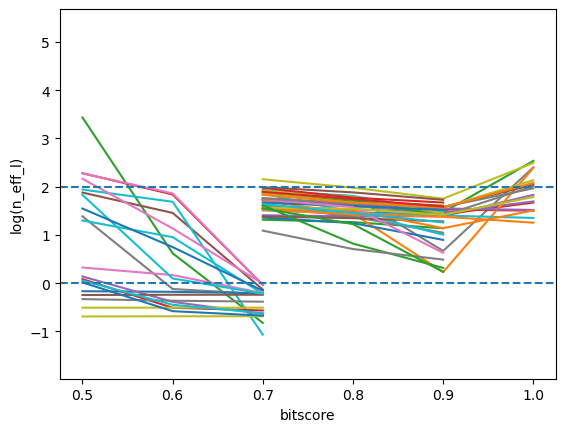

In [18]:
subset_aln_stats_full.apply(np.log10).plot.line(legend=False)
plt.axhline(0, linestyle='--')
plt.axhline(2, linestyle='--')
plt.ylabel('log(n_eff_l)')
plt.savefig('scripts/Beltran_Lehner_2025/Neff_L_bitscore_elbow_plot.pdf')

/tmp/ipykernel_24013/3695607886.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  PF00096_seq.fillna(method='ffill').apply(np.log10).plot.line(legend=False)


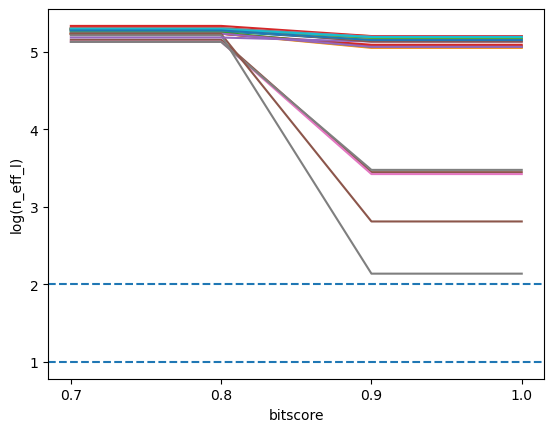

In [19]:
PF00096_seq = subset_aln_stats_full.filter(regex='_PF00096_')
PF00096_seq.fillna(method='ffill').apply(np.log10).plot.line(legend=False)
plt.axhline(1, linestyle='--')
plt.axhline(2, linestyle='--')
plt.ylabel('log(n_eff_l)')
plt.xticks([0.7, 0.8, 0.9, 1.0])
plt.savefig('scripts/Beltran_Lehner_2025/Neff_L_bitscore_elbow_plot_PF00096.pdf')

Conclusion: Neff/L = 100 may be ok, since most sequences have an elbow point, if applicable, between 10 and 100. 

Double check with column cov > 0.8 filter

Text(0, 0.5, 'log(n_eff_l)')

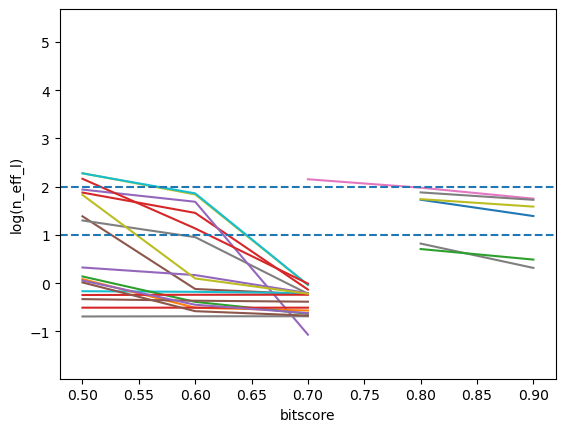

In [31]:
aln_stats_full_pivot_cov = aln_stats_full[aln_stats_full['perc_cov'] >= 0.8].pivot(index='bitscore', columns='protein', values='n_eff_l')
non_nan_counts = aln_stats_full_pivot_cov.notna().sum()
columns_to_keep = non_nan_counts[non_nan_counts > 1].index
subset_aln_stats_full_cov = aln_stats_full_pivot_cov[columns_to_keep]
subset_aln_stats_full_cov

subset_aln_stats_full_cov.apply(np.log10).plot.line(legend=False)
plt.axhline(np.log10(100), linestyle='--')
plt.axhline(1, linestyle='--')
plt.ylabel('log(n_eff_l)')

Same conclusion as above, can set Neff_L = 100 as a max, meaning that if we have an MSA with Neff/L > 100, we run it again at a higher bitscore, unless we already have the current bitscore = 1.0, then we pick the bitscore that results in Neff_L < 100 for those proteins.

Not an important plot, just to visualize the overall distribution of Neff/L over different bitscores, without distinguishing which protein is visualized

/tmp/ipykernel_24013/1116770423.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aln_stats_df_filtered['bitscore'] = 0.7


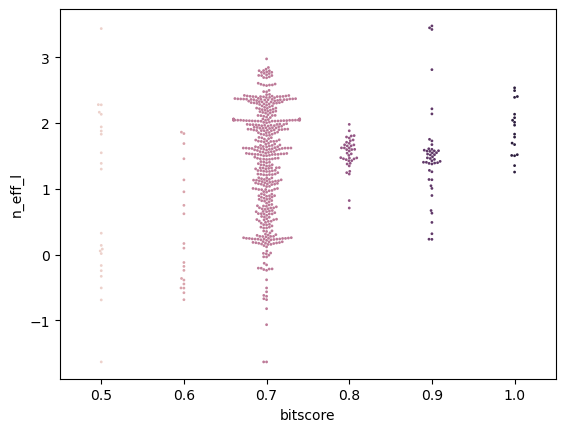

In [20]:
aln_stats_df_filtered = aln_stats_df[aln_stats_df['num_seqs'] < 2000000] # because as of 6/2/2025 we only actually calculate Neff_L for num_seqs < 500000
aln_stats_df_filtered['bitscore'] = 0.7

rerun_df_filtered = rerun_df_full[rerun_df_full['num_seqs'] < 2000000]

bitscore_plot_df = pd.concat([aln_stats_df_filtered, rerun_df_filtered], ignore_index=True, axis=0)
bitscore_plot_df['n_eff_l'] = np.log10(bitscore_plot_df['n_eff_l'])
sns.swarmplot(data=bitscore_plot_df, x="bitscore", y="n_eff_l", hue="bitscore", size=2)
plt.legend().remove()
plt.show()

In [21]:
rerun_df_filtered = rerun_df_full[rerun_df_full['num_seqs'] < 2000000]
rerun_df_filtered["bitscore"].value_counts()

bitscore
0.9    46
0.8    40
0.5    22
0.6    20
1.0    18
Name: count, dtype: int64

**Conclusion: set Neff_L = 100 as the cutoff, rerun the MSA if none of the current bitscore yields anything within Neff_L = 1-100**

### Figure out protein sequences to rerun
1. If all the current runs give over 2M sequences --> rerun at a higher bitscore (unless the highest bitscore is 1, then abort the sequence)
2. If all the current runs give Neff_L > 100 --> rerun at a higher bitscore (unless the highest bitscore is 1, then abort the sequence)

After the rerun, implement a function to choose different bitscores, if for a sequence, alignments from more than 1 bitscore fulfill the requirements:
1. less than 2M sequences
2. Neff/L is between 1-100 (choose the one that is closest to 100, but smaller than 100) - allowing some flexibility < 150 is ok
3. perc_cov > 0.8
4. Exceptions:
- In the case where Neff/L is smaller than 1 and perc_cov < 0.8 for all bitscores, choose the one with the highest Neff/L
- In the case where perc_cov < 0.8 for all bitscores, choose the one with the highest Neff/L that is closest to 100

In [11]:
max_n_eff_l = 150
min_n_eff_l = 1
max_num_seq = 2000000
min_perc_cov = 0.8

In [13]:
# same as before
def good_run_condition(x, max_n_eff_l=max_n_eff_l, min_n_eff_l=min_n_eff_l, max_num_seq=max_num_seq, min_perc_cov=min_perc_cov):
    return (((x['n_eff_l'] <= max_n_eff_l) & (x['n_eff_l'] >= min_n_eff_l)) & (x['num_seqs'] <= max_num_seq) & (np.round(x['perc_cov'], 2) >= min_perc_cov)).any()

# changing
def rerun_higher_bitscore_condition(x, 
                                    max_n_eff_l=max_n_eff_l, min_n_eff_l=min_n_eff_l, max_num_seq=max_num_seq, min_perc_cov=min_perc_cov):
    return (
        (x['n_eff_l'] > max_n_eff_l) | 
        (x['num_seqs'] > max_num_seq) |
        (
            ((x['n_eff_l'] <= max_n_eff_l) & (x['n_eff_l'] >= min_n_eff_l)) & 
            (x['num_seqs'] <= max_num_seq) & 
            (np.round(x['perc_cov'], 2) < min_perc_cov)
        )
    ).all()
                          
aln_stats_good = aln_stats_full.groupby('protein').filter(good_run_condition)
aln_stats_rerun_higher = aln_stats_full.groupby('protein').filter(rerun_higher_bitscore_condition)
# aln_stats_rerun_lower = aln_stats_full.groupby('protein').filter(rerun_lower_bitscore_condition)

Check the aws rerun (don't rerun the below cells, as we merged the aws rerun bitscore 0.8, 0.9 to the previous runs)

In [51]:
aws_8_aln_stats_df = pd.read_csv('output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_bitscore_0.8_aws_fixerror_aln_stats.csv')
aws_8_aln_stats_df['bitscore'] = 0.8
aws_9_aln_stats_df = pd.read_csv('output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_bitscore_0.9_aws_fixerror_aln_stats.csv')
aws_9_aln_stats_df['bitscore'] = 0.9
aws_aln_stats_df = pd.concat([aws_8_aln_stats_df, aws_9_aln_stats_df], ignore_index=True,axis=0).sort_values(by=['protein'])
print(aws_aln_stats_df.head())

aws_aln_stats_good = aws_aln_stats_df.groupby('protein').filter(good_run_condition)
aws_aln_stats_higher = aws_aln_stats_df.groupby('protein').filter(rerun_higher_bitscore_condition)

               protein  num_seqs  num_seqs_unfiltered  perc_filtered  \
0   O75400_PF00397_176     25232                25252       0.999208   
17  O75400_PF00397_176     21298                21317       0.999109   
1   P39940_PF00397_324    160272               160349       0.999520   
18  P39940_PF00397_324    136379               136440       0.999553   
19  P46937_PF00397_165    126484               126544       0.999526   

          n_eff    n_eff_l  seq_len  num_cov  perc_cov  bitscore  
0    939.650296  18.424516       51       38  0.745098       0.8  
17   700.096322  13.727379       51       39  0.764706       0.9  
1   2193.456715  51.010621       43       33  0.767442       0.8  
18  1746.099909  40.606975       43       33  0.767442       0.9  
19  1617.604506  35.165315       46       34  0.739130       0.9  


#### Sanity check 1: Make sure all proteins are covered
Check if the good sequences and the sequences to rerun at higher bitscores are non-overlapping and cover all the 522 sequences in the Domainome

In [25]:
print(f"{aln_stats_full['protein'].nunique()} proteins in total")
print(f"{aln_stats_good['protein'].nunique()} proteins look good, though some may benefit from a lower bitscore")
print(f"{aln_stats_rerun_higher['protein'].nunique()} proteins need to rerun at a higher bitscore")
print(f"{aln_stats_rerun_lower['protein'].nunique()} proteins need to rerun at a lower bitscore")
print(f"{aln_stats_low_n_eff_l['protein'].nunique()} proteins will remain at low Neff/L")

522 proteins in total
356 proteins look good, though some may benefit from a lower bitscore
158 proteins need to rerun at a higher bitscore
6 proteins need to rerun at a lower bitscore
0 proteins will remain at low Neff/L


Figure out where the 10 missing proteins are

In [36]:
full_protein_set = set(aln_stats_full['protein'].tolist())
good_protein_set = set(aln_stats_good['protein'].tolist())
rerun_higher_protein_set = set(aln_stats_rerun_higher['protein'].tolist())
rerun_lower_protein_set = set(aln_stats_rerun_lower['protein'].tolist())

In [37]:
good_protein_set & rerun_higher_protein_set

set()

In [38]:
good_protein_set & rerun_lower_protein_set

set()

In [39]:
rerun_higher_protein_set & rerun_lower_protein_set

set()

In [40]:
full_protein_set - (good_protein_set | rerun_higher_protein_set | rerun_lower_protein_set)

{'EHEE-rd1-0882_rockdoms_1', 'Q9NYL2_PF00536_330'}

In [41]:
aln_stats_full[aln_stats_full['protein'] == 'EHEE-rd1-0882_rockdoms_1']

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
7,EHEE-rd1-0882_rockdoms_1,8,8,1.000000,6.000000,0.150000,40,30,0.75,0.7
519,EHEE-rd1-0882_rockdoms_1,461951,462120,0.999634,109295.701468,2732.392537,40,30,0.75,0.5
520,EHEE-rd1-0882_rockdoms_1,582,582,1.000000,166.602763,4.165069,40,28,0.70,0.6


Manually include `EHEE-rd1-0882_rockdoms_1` (but exclude when scoring) at bitscore = 0.6

In [44]:
aln_stats_full[aln_stats_full['protein'] == 'Q9NYL2_PF00536_330'].sort_values(by=['bitscore'], ascending=True)

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
669,Q9NYL2_PF00536_330,45312,45357,0.999008,2960.307601,35.241757,84,66,0.785714,0.5
670,Q9NYL2_PF00536_330,11488,11502,0.998783,470.748217,5.604145,84,66,0.785714,0.6
465,Q9NYL2_PF00536_330,1351,1354,0.997784,58.478195,0.696169,84,83,0.988095,0.7


Manually include `Q9NYL2_PF00536_330` at bitscore = 0.5

array([[<Axes: title={'center': 'seq_len'}>]], dtype=object)

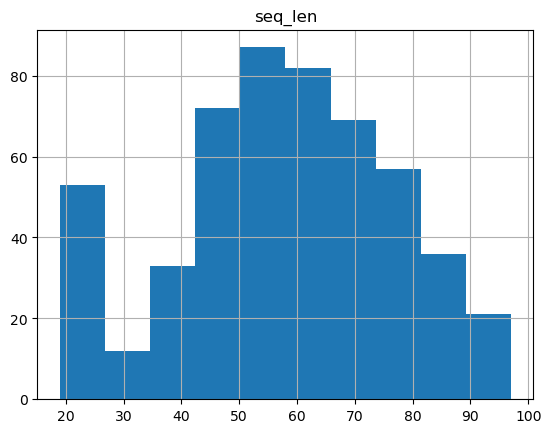

In [47]:
aln_stats_full[['protein', 'seq_len']].drop_duplicates().hist(column='seq_len')

In [42]:
aws_aln_stats_good

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
3,P82979_PF02037_3,33338,33383,0.998652,2418.704558,53.748990,45,37,0.822222,0.8
20,P82979_PF02037_3,22799,22814,0.999343,1108.431760,24.631817,45,37,0.822222,0.9
21,Q14151_PF02037_27,27566,27574,0.999710,1349.186461,30.663329,44,37,0.840909,0.9
4,Q14151_PF02037_27,35883,35931,0.998664,2832.396518,64.372648,44,34,0.772727,0.8
5,Q15424_PF02037_26,16471,16479,0.999515,966.661541,17.575664,55,41,0.745455,0.8
22,Q15424_PF02037_26,7450,7457,0.999061,434.357558,7.897410,55,50,0.909091,0.9
7,Q8IX12_PF02037_625,20092,20096,0.999801,1190.970662,23.819413,50,37,0.740000,0.8
24,Q8IX12_PF02037_625,8279,8280,0.999879,555.436486,11.108730,50,40,0.800000,0.9
26,Q969V6_PF02037_341,27052,27095,0.998413,2019.056063,46.954792,43,35,0.813953,0.9
9,Q969V6_PF02037_341,31721,31766,0.998583,2546.167366,59.213195,43,34,0.790698,0.8


array([[<Axes: title={'center': 'seq_len'}>]], dtype=object)

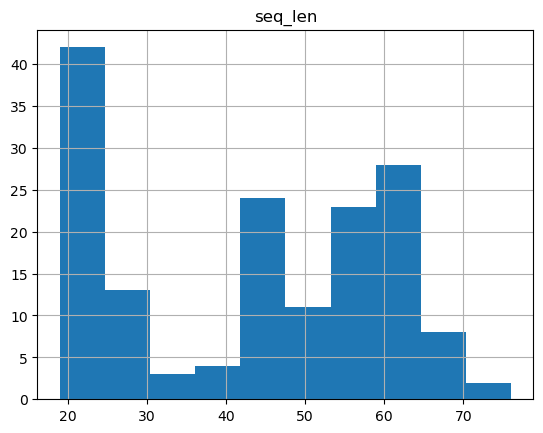

In [48]:
aln_stats_rerun_higher[['protein', 'seq_len']].drop_duplicates().hist(column='seq_len')

All proteins are covered

#### Sanity check 2: among the good sequences, pick the best bitscore based on Neff_L and perc_cov
- Among these sequences, alignment under at least one bitscore satisfies the criteria 
- remove sequences that have very low num_seqs **None of the sequences falls under this**

In [49]:
aln_stats_good.sort_values(by=['protein', 'bitscore'], ascending=True)

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
0,A0A2R8Y422_PF00240_2,61139,61559,0.993177,5929.079783,84.701140,70,68,0.971429,0.7
4,A2RRE5_PF01846_267,4527,4543,0.996478,128.704577,2.042930,63,60,0.952381,0.7
5,A6NK59_PF07525_532,29706,29746,0.998655,2172.122054,52.978587,41,36,0.878049,0.7
521,HHH-rd1-0142_rockdoms_1,95906,96071,0.998283,5839.246049,135.796420,43,35,0.813953,0.5
8,HHH-rd1-0142_rockdoms_1,1,1,1.000000,1.000000,0.023256,43,43,1.000000,0.7
...,...,...,...,...,...,...,...,...,...,...
509,Q9Y4I5_PF03638_368,16483,16489,0.999636,675.174096,18.754836,36,34,0.944444,0.7
510,Q9Y4J8_PF00569_235,53287,53319,0.999400,3156.788418,52.613140,60,52,0.866667,0.7
514,Q9Y618_PF00249_613,57496,57518,0.999618,1467.850172,25.307762,58,48,0.827586,0.7
515,Q9Y6N9_PF00595_207,123241,123337,0.999222,1477.509933,16.601235,89,74,0.831461,0.7


Choose the bitscore that gives rise to N_eff/L closest to 100 (not higher than 150) for each protein, while guaranteeing that num_seqs < 2000000 and perc_cov > 0.8

In [61]:
def find_bitscore(df):
    best_row = df['n_eff_l'].idxmax()
    return df.loc[best_row]

def choose_best_bitscore(df, max_num_seq=2000000, min_perc_cov=0.8, max_n_eff_l=150):
    df = df[(df['num_seqs'] < max_num_seq) & (np.round(df['perc_cov'], 2) >= min_perc_cov) & (df['n_eff_l'] <= max_n_eff_l)]
    return df.groupby('protein').apply(find_bitscore)

aln_stats_good_bitscore = choose_best_bitscore(aln_stats_good)
aln_stats_good_bitscore

/tmp/ipykernel_24013/2286078819.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('protein').apply(find_bitscore)


,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
protein,,,,,,,,,,
A0A2R8Y422_PF00240_2,A0A2R8Y422_PF00240_2,61139,61559,0.993177,5929.079783,84.701140,70,68,0.971429,0.7
A2RRE5_PF01846_267,A2RRE5_PF01846_267,4527,4543,0.996478,128.704577,2.042930,63,60,0.952381,0.7
A6NK59_PF07525_532,A6NK59_PF07525_532,29706,29746,0.998655,2172.122054,52.978587,41,36,0.878049,0.7
HHH-rd1-0142_rockdoms_1,HHH-rd1-0142_rockdoms_1,95906,96071,0.998283,5839.246049,135.796420,43,35,0.813953,0.5
O14529_PF02376_1036,O14529_PF02376_1036,24578,24608,0.998781,178.426901,2.004797,89,78,0.876404,0.7
...,...,...,...,...,...,...,...,...,...,...
Q9Y4I5_PF03638_368,Q9Y4I5_PF03638_368,16483,16489,0.999636,675.174096,18.754836,36,34,0.944444,0.7
Q9Y4J8_PF00569_235,Q9Y4J8_PF00569_235,53287,53319,0.999400,3156.788418,52.613140,60,52,0.866667,0.7
Q9Y618_PF00249_613,Q9Y618_PF00249_613,57496,57518,0.999618,1467.850172,25.307762,58,48,0.827586,0.7


array([[<Axes: title={'center': 'seq_len'}>]], dtype=object)

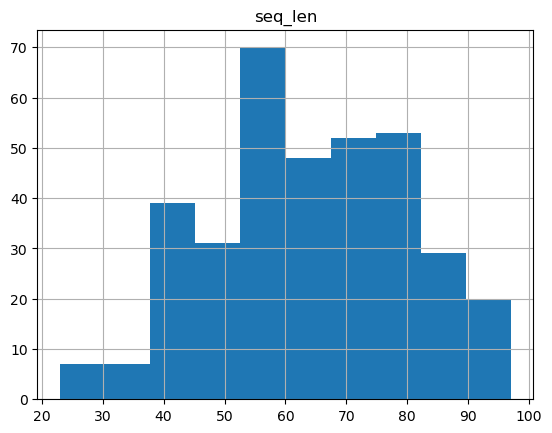

In [52]:
aln_stats_good_bitscore[['protein', 'seq_len']].drop_duplicates().hist(column='seq_len')

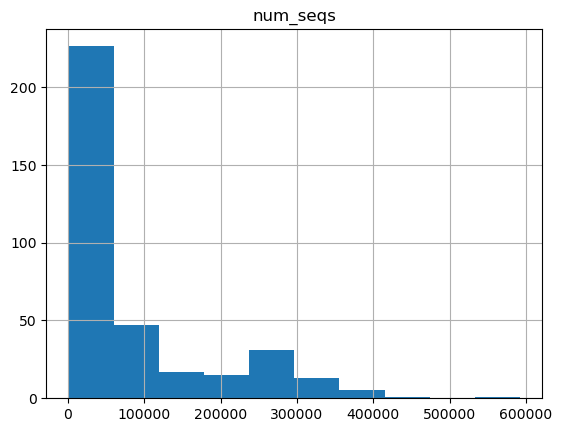

In [53]:
aln_stats_good_bitscore.hist(column='num_seqs')
plt.show()

Further plot the distribution among those with <1000 sequences

In [56]:
aln_stats_good_bitscore[aln_stats_good_bitscore["num_seqs"] < 1000]

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
protein,,,,,,,,,,


**Conclusion: all alignments have at least 1000 sequences, good for now**

#### Sanity check 2.2 (not running this section)
These sequences, at the currently optimal bitscore, may benefit from a run at a lower bitscore, unless the run has been done already 

Check the max n_eff_l of each sequence, see if it's very close to 1

In [58]:
aln_stats_good_bitscore[aln_stats_good_bitscore['n_eff_l'] < 10]

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
protein,,,,,,,,,,
A2RRE5_PF01846_267,A2RRE5_PF01846_267,4527,4543,0.996478,128.704577,2.042930,63,60,0.952381,0.7
O14529_PF02376_1036,O14529_PF02376_1036,24578,24608,0.998781,178.426901,2.004797,89,78,0.876404,0.7
O14529_PF02376_895,O14529_PF02376_895,24743,24769,0.998950,180.301437,2.613064,69,67,0.971014,0.7
O14640_PF00778_4,O14640_PF00778_4,13349,13362,0.999027,262.507509,3.365481,78,72,0.923077,0.7
O14776_PF01846_645,O14776_PF01846_645,11991,11998,0.999417,237.606136,3.443567,69,57,0.826087,0.7
...,...,...,...,...,...,...,...,...,...,...
Q9UPQ7_PF00595_414,Q9UPQ7_PF00595_414,5819,5826,0.998798,123.122426,1.368027,90,90,1.000000,0.7
Q9UPW6_PF02376_358,Q9UPW6_PF02376_358,12508,12542,0.997289,87.202794,1.132504,77,68,0.883117,0.5
Q9UPW6_PF02376_482,Q9UPW6_PF02376_482,12531,12564,0.997373,77.561672,1.034156,75,68,0.906667,0.5


In [14]:
def suggest_lower_bitscore_run(df_full, df_filtered, n_eff_l_intermediate_threshold=10):
    # get the sequences that may benefit from a lower bitscore
    df_low_n_eff_l = df_filtered[df_filtered['n_eff_l'] < n_eff_l_intermediate_threshold]
    # check if they have already been run at a lower bitscore prior to filtering, if not, output the sequence at the current bitscore - 0.1 and current bitscore - 0.2
    list_rerun = []
    for _, row in df_low_n_eff_l.iterrows():
        if (row['bitscore'] - 0.1) in df_full.loc[df_full['protein'] == row['protein'], 'bitscore']:
            continue
        else:
            list_rerun.extend([[row['protein'], row['bitscore'] - 0.1], [row['protein'], row['bitscore'] - 0.2]])
    df_rerun = pd.DataFrame(list_rerun, columns=['protein', 'bitscore'])
    return df_rerun

In [15]:
lower_bitscore_run_df = suggest_lower_bitscore_run(aln_stats_full, aln_stats_good)

For now keep them the way there are, because we'd like to see model performance on sequences at bitscore over all difference ranges.

#### Sanity check 3: sequences to rerun at higher bitscores
- ~if it contains PF00096, remove~ For all PF00096 (lots of failed runs at bitscore=1.0, try bitscore=1.2)
- for all others, run at bitscore=1.2

In [59]:
aln_stats_rerun_higher.sort_values(by=['protein', 'bitscore'], ascending=True)

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
1,A0PJY2_PF00096_289,4082271,4087406,0.998744,4.082271e+06,185557.772727,22,21,0.954545,0.7
517,A0PJY2_PF00096_289,3092510,3096441,0.998730,3.092510e+06,140568.636364,22,21,0.954545,0.9
2,A1X283_PF00018_155,514408,514768,0.999301,1.442098e+04,262.199550,55,49,0.890909,0.7
3,A1X283_PF00018_222,503000,503356,0.999293,1.443939e+04,244.735369,59,50,0.847458,0.7
9,O00308_PF00397_440,93373,93416,0.999540,1.380335e+03,25.561763,54,38,0.703704,0.7
...,...,...,...,...,...,...,...,...,...,...
508,Q9Y462_PF00096_506,4154305,4159285,0.998803,4.154305e+06,188832.045455,22,21,0.954545,0.7
693,Q9Y462_PF00096_506,3124430,3128293,0.998765,3.124430e+06,142019.545455,22,21,0.954545,0.9
511,Q9Y5K6_PF00018_271,487664,487976,0.999361,1.215360e+04,199.239283,61,51,0.836066,0.7
513,Q9Y5K6_PF14604_1,510289,510619,0.999354,1.383689e+04,234.523617,59,50,0.847458,0.7


Find the maximum bitscore and increase till it hits `max_bitscore=1.2` 

In [87]:
def find_bitscore(df):
    best_row = df['n_eff_l'].idxmax()
    return df.loc[best_row]

def generate_bitscore(bitscore, max_bitscore=1.2, bitscore_interval=0.2):
    bitscore_list = []
    while np.round(bitscore, 2) < max_bitscore:
        bitscore += bitscore_interval
        if bitscore < max_bitscore:
            bitscore_list.append(np.round(bitscore, 2))
    if len(bitscore_list) == 0:
        bitscore_list = [1.1]
    return bitscore_list

def suggest_higher_bitscore_run(df_full, df, max_bitscore=1.2):
    # find the highest bitscore
    df_highest_bitscore = df.groupby('protein').apply(find_bitscore)
    
    list_rerun = []
    for _, row in df_highest_bitscore.iterrows():
        if "_PF00096_" in row['protein']:
            list_rerun.append([row['protein'], max_bitscore])
        else:
            bitscore_list = generate_bitscore(row['bitscore'])
            for bitscore in bitscore_list:
                list_rerun.append([row['protein'], bitscore])
    df_rerun = pd.DataFrame(list_rerun, columns=['protein', 'bitscore'])
    return df_rerun

In [88]:
higher_bitscore_run_df = suggest_higher_bitscore_run(aln_stats_full, aln_stats_rerun_higher)

/tmp/ipykernel_24013/2301833182.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_highest_bitscore = df.groupby('protein').apply(find_bitscore)


In [89]:
higher_bitscore_run_df

,protein,bitscore
0,A0PJY2_PF00096_289,1.2
1,A1X283_PF00018_155,0.9
2,A1X283_PF00018_155,1.1
3,A1X283_PF00018_222,0.9
4,A1X283_PF00018_222,1.1
...,...,...
266,Q9Y5K6_PF00018_271,1.1
267,Q9Y5K6_PF14604_1,0.9
268,Q9Y5K6_PF14604_1,1.1
269,Q9Y5K6_PF14604_109,0.9


In [90]:
higher_bitscore_run_df['protein'].nunique()

158

Check if these suggested higher bitscores have been run

In [96]:
aws_rerun_list3 = []
for _, row in higher_bitscore_run_df.iterrows():
    protein = row['protein']
    bit = row['bitscore']
    a2m = f"./output/Beltran_Lehner_2025/uniref100/{protein}/{protein}_bit_{bit}_theta_0.8_colcov_0/align/{protein}_bit_{bit}_theta_0.8_colcov_0.a2m"
    if not exists(a2m):
        print(row)
        aws_rerun_list3.append(protein)
        # print(aln_stats_rerun_higher[aln_stats_rerun_higher['protein']==protein])

protein     O00308_PF00397_440
bitscore                   1.1
Name: 5, dtype: object
protein     O95817_PF00397_11
bitscore                  1.1
Name: 35, dtype: object
protein     P40040_PF02037_1
bitscore                 1.1
Name: 85, dtype: object
protein     P46934_PF00397_836
bitscore                   1.1
Name: 89, dtype: object
protein     P46937_PF00397_162
bitscore                   1.1
Name: 90, dtype: object
protein     P46937_PF00397_226
bitscore                   1.1
Name: 94, dtype: object
protein     Q86UL8_PF00397_296
bitscore                   1.1
Name: 161, dtype: object
protein     Q8N3X1_PF00397_593
bitscore                   1.1
Name: 173, dtype: object
protein     Q96J02_PF00397_428
bitscore                   1.1
Name: 196, dtype: object
protein     Q96J02_PF00397_474
bitscore                   1.1
Name: 198, dtype: object
protein     Q96PU5_PF00397_184
bitscore                   1.1
Name: 201, dtype: object
protein     Q96PU5_PF00397_381
bitscore                 

#### Sanity check 3.1 sequences that are missing: higher bitscore correlates with lower perc_cov

In [74]:
aln_stats_rerun_higher[aln_stats_rerun_higher['protein'] == 'P46934_PF00397_836']

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
186,P46934_PF00397_836,159217,159293,0.999523,2409.332680,52.376797,46,34,0.739130,0.7
556,P46934_PF00397_836,145034,145101,0.999538,1923.963012,41.825283,46,35,0.760870,0.8
557,P46934_PF00397_836,124327,124378,0.999590,1551.944024,33.737914,46,34,0.739130,0.9
558,P46934_PF00397_836,73470,73487,0.999769,1463.222591,31.809187,46,33,0.717391,1.0


In [76]:
aln_stats_rerun_higher[aln_stats_rerun_higher['protein'] == 'P46937_PF00397_162']

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
187,P46937_PF00397_162,127493,127549,0.999561,1950.412315,39.008246,50,37,0.74,0.7
559,P46937_PF00397_162,106541,106585,0.999587,1442.851862,28.857037,50,37,0.74,0.9
560,P46937_PF00397_162,112907,112959,0.999540,1699.827682,33.996554,50,37,0.74,0.8
561,P46937_PF00397_162,47513,47532,0.999600,2475.534829,49.510697,50,35,0.70,1.0


In [77]:
aln_stats_rerun_higher[aln_stats_rerun_higher['protein'] == 'Q9GZV5_PF00397_116']

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
435,Q9GZV5_PF00397_116,158089,158163,0.999532,2671.448131,56.839322,47,35,0.744681,0.7
647,Q9GZV5_PF00397_116,149406,149468,0.999585,2106.604249,44.821367,47,35,0.744681,0.8
648,Q9GZV5_PF00397_116,121199,121252,0.999563,4357.762945,92.718361,47,34,0.723404,1.0
649,Q9GZV5_PF00397_116,125518,125578,0.999522,1781.516549,37.904607,47,35,0.744681,0.9


In [80]:
aln_stats_rerun_higher[aln_stats_rerun_higher['protein'] == 'P40040_PF02037_1']

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
177,P40040_PF02037_1,25894,25936,0.998381,2720.039424,55.511009,49,38,0.775510,0.7
553,P40040_PF02037_1,19549,19584,0.998213,1934.463233,39.478841,49,37,0.755102,0.8
554,P40040_PF02037_1,74384,74453,0.999073,16820.555681,343.276647,49,35,0.714286,1.0
555,P40040_PF02037_1,14765,14798,0.997770,1447.376826,29.538303,49,37,0.755102,0.9


Rerun EVCouplings at bitscore 1.1 and see how the trend goes

In [97]:
conv_list_to_csv(aws_rerun_list3, 'input/Beltran_Lehner_2025/sequences_1.1_aws_rerun2.csv')

#### AWS

In [43]:
aws_aln_stats_higher

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
0,O75400_PF00397_176,25232,25252,0.999208,939.650296,18.424516,51,38,0.745098,0.8
17,O75400_PF00397_176,21298,21317,0.999109,700.096322,13.727379,51,39,0.764706,0.9
1,P39940_PF00397_324,160272,160349,0.999520,2193.456715,51.010621,43,33,0.767442,0.8
18,P39940_PF00397_324,136379,136440,0.999553,1746.099909,40.606975,43,33,0.767442,0.9
19,P46937_PF00397_165,126484,126544,0.999526,1617.604506,35.165315,46,34,0.739130,0.9
2,P46937_PF00397_165,149699,149767,0.999546,1920.359655,41.746949,46,34,0.739130,0.8
6,Q5TCQ9_PF00397_287,156142,156217,0.999520,2111.486432,49.104336,43,33,0.767442,0.8
23,Q5TCQ9_PF00397_287,131884,131943,0.999553,1711.556423,39.803638,43,33,0.767442,0.9
8,Q8IZQ8_PF02037_363,33213,33267,0.998377,2697.519458,61.307260,44,33,0.750000,0.8
25,Q8IZQ8_PF02037_363,20889,20922,0.998423,1232.522832,28.011883,44,34,0.772727,0.9


Rerun the above 6 sequences at bitscore = 1 and 1.1

In [15]:
aws_rerun_list2 = aws_aln_stats_higher['protein'].unique().tolist()
conv_list_to_csv(aws_rerun_list2, 'input/Beltran_Lehner_2025/sequences_1_aws_rerun.csv')
conv_list_to_csv(aws_rerun_list2, 'input/Beltran_Lehner_2025/sequences_1.1_aws_rerun.csv')

Calculate alignment stats on AWS

In [16]:
bitscore_list = [1, 1.1]
a2m_root_dir = './output/Beltran_Lehner_2025/'
for bit in bitscore_list:
    # grab the .a2m files
    a2m_dir = a2m_root_dir + f"bitscore{bit}_a2m/"
    os.makedirs(a2m_dir, exist_ok=True)
    protein_list = aws_rerun_list2
    # generate the mapping .csv
    mapping_file = f"./output/Beltran_Lehner_2025/mappings/beltran_domains_jackhmmer_bitscore_{bit}_mapping_aws_fixerror.csv"
    with open(mapping_file, 'w') as f_out:
        f_out.write('protein_name,msa_location,theta\n')    
        for protein in protein_list:
            src_a2m_file = f"./output/Beltran_Lehner_2025/uniref100/{protein}/{protein}_bit_{bit}_theta_0.8_colcov_0/align/{protein}_bit_{bit}_theta_0.8_colcov_0.a2m"

            if exists(src_a2m_file):
                # copy the .a2m files
                shutil.copy2(src_a2m_file, a2m_dir)
                # add entry to the mapping file
                protein_name = protein
                f_out.write(f"{protein},{basename(src_a2m_file)},0.2\n")

In [8]:
a2m_root_dir = './output/Beltran_Lehner_2025/'
bit = 1.1
# grab the .a2m files
a2m_dir = a2m_root_dir + f"bitscore{bit}_a2m/"
os.makedirs(a2m_dir, exist_ok=True)
aws_rerun_list3 = pd.read_csv('input/Beltran_Lehner_2025/sequences_1.1_aws_rerun2.csv')
protein_list = aws_rerun_list3['UniProt_ID'].tolist()
# generate the mapping .csv
mapping_file = f"./output/Beltran_Lehner_2025/mappings/beltran_domains_jackhmmer_bitscore_{bit}_mapping_aws_fixerror2.csv"
with open(mapping_file, 'w') as f_out:
    f_out.write('protein_name,msa_location,theta\n')    
    for protein in protein_list:
        src_a2m_file = f"./output/Beltran_Lehner_2025/uniref100/{protein}/{protein}_bit_{bit}_theta_0.8_colcov_0/align/{protein}_bit_{bit}_theta_0.8_colcov_0.a2m"

        if exists(src_a2m_file):
            # copy the .a2m files
            shutil.copy2(src_a2m_file, a2m_dir)
            # add entry to the mapping file
            protein_name = protein
            f_out.write(f"{protein},{basename(src_a2m_file)},0.2\n")
        else:
            print(f"Error: {src_a2m_file} doesn't exist!!!")

#### Sanity check 4: sequences with very low N_eff_l (<1)

In [92]:
aln_stats_rerun_lower.sort_values(by=['protein', 'bitscore'], ascending=True)

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
518,EEHEE-rd3-0037_rockdoms_1,1,1,1.000000,1.000000,0.023256,43,43,1.000000,0.5
6,EEHEE-rd3-0037_rockdoms_1,1,1,1.000000,1.000000,0.023256,43,43,1.000000,0.7
568,P55895_PF13341_415,1295,1330,0.973684,15.692192,0.203795,77,77,1.000000,0.5
569,P55895_PF13341_415,1295,1330,0.973684,15.821530,0.205474,77,77,1.000000,0.6
211,P55895_PF13341_415,1295,1330,0.973684,15.847524,0.205812,77,77,1.000000,0.7
571,P61960_PF03671_4,1735,1747,0.993131,50.370649,0.680684,74,74,1.000000,0.5
572,P61960_PF03671_4,1734,1746,0.993127,48.892061,0.660704,74,74,1.000000,0.6
219,P61960_PF03671_4,1741,1753,0.993155,45.835868,0.619404,74,74,1.000000,0.7
582,Q01826_PF16557_178,3776,3783,0.998150,39.753770,0.567911,70,70,1.000000,0.5
583,Q01826_PF16557_178,3775,3782,0.998149,40.212104,0.574459,70,70,1.000000,0.6


**Issue:**
`P55895_PF13341_415` have different n_eff but the .a2m files are the same size (md5sum are different) - maybe the same sequences in different order? Why is n_eff different?

Keep all sequences with >100 sequences and use the bitscore with the highest n_eff_l

In [93]:
low_n_eff_l_df = aln_stats_rerun_lower[aln_stats_rerun_lower['num_seqs'] > 100].groupby('protein').apply(find_bitscore)

/tmp/ipykernel_24013/1995158091.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  low_n_eff_l_df = aln_stats_rerun_lower[aln_stats_rerun_lower['num_seqs'] > 100].groupby('protein').apply(find_bitscore)


In [94]:
low_n_eff_l_df

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
protein,,,,,,,,,,
P55895_PF13341_415,P55895_PF13341_415,1295,1330,0.973684,15.847524,0.205812,77,77,1.000000,0.7
P61960_PF03671_4,P61960_PF03671_4,1735,1747,0.993131,50.370649,0.680684,74,74,1.000000,0.5
Q01826_PF16557_178,Q01826_PF16557_178,3775,3782,0.998149,40.253770,0.575054,70,70,1.000000,0.7
Q13163_PF00564_15,Q13163_PF00564_15,1971,1971,1.000000,44.319275,0.466519,95,94,0.989474,0.5
Q9UL15_PF02179_280,Q9UL15_PF02179_280,1189,1194,0.995812,21.401262,0.310163,69,69,1.000000,0.6


#### Summary (n=522 proteins in total):
1. 356 proteins look good, Neff/L ranging from 1-150, perc_cov > 80%, number of sequences < 2M
2. 158 proteins have either very high number of sequences or large Neff/L (over 150) and perc_cov > 80%, will be rerun at higher bitscores up to 1.2
- currently running 11 sequences that were missing at bitscore=1.1
- many show abnormal increase of Neff/L with increasing bitscores
3. 6 proteins have n_eff_l < 1 after trying out bitscores 0.5-0.7; After removing `EEHEE-rd3-0037_rockdoms_1` for small number of sequences 5 proteins remain

In [102]:
bitscore_9_round3 = higher_bitscore_run_df[higher_bitscore_run_df['bitscore'] == 0.9]['protein'].tolist()
bitscore_11_round3 = higher_bitscore_run_df[higher_bitscore_run_df['bitscore'] == 1.1]['protein'].tolist()
bitscore_12_round3 = higher_bitscore_run_df[higher_bitscore_run_df['bitscore'] == 1.2]['protein'].tolist()

conv_list_to_csv(bitscore_9_round3, 'input/Beltran_Lehner_2025/sequences_0.9_round3.csv')
conv_list_to_csv(bitscore_11_round3, 'input/Beltran_Lehner_2025/sequences_1.1_round3.csv')
conv_list_to_csv(bitscore_12_round3, 'input/Beltran_Lehner_2025/sequences_1.2_round3.csv')

In [103]:
print(len(bitscore_9_round3), len(bitscore_11_round3), len(bitscore_12_round3))

102 102 35


## Calculate alignment stats for round 3

All the reruns finished successfully

Make the mapping files

In [20]:
bitscore_9_round3 = pd.read_csv('input/Beltran_Lehner_2025/sequences_0.9_round3.csv')
bitscore_11_round3 = pd.read_csv('input/Beltran_Lehner_2025/sequences_1.1_round3.csv')
bitscore_12_round3 = pd.read_csv('input/Beltran_Lehner_2025/sequences_1.2_round3.csv')

In [16]:
bitscore_list = [0.9, 1.1, 1.2]
bitscore_file_list = [bitscore_9_round3, bitscore_11_round3, bitscore_12_round3]
a2m_root_dir = './output/Beltran_Lehner_2025/'
for i, bit in enumerate(bitscore_list):
    # grab the .a2m files
    a2m_dir = a2m_root_dir + f"bitscore{bit}_a2m/"
    os.makedirs(a2m_dir, exist_ok=True)
    protein_list = bitscore_file_list[i]['UniProt_ID'].tolist()
    # generate the mapping .csv
    mapping_file = f"./output/Beltran_Lehner_2025/mappings/beltran_domains_jackhmmer_bitscore_{bit}_mapping_round3.csv"
    with open(mapping_file, 'w') as f_out:
        f_out.write('protein_name,msa_location,theta\n')    
        for protein in protein_list:
            src_a2m_file = f"./output/Beltran_Lehner_2025/uniref100/{protein}/{protein}_bit_{bit}_theta_0.8_colcov_0/align/{protein}_bit_{bit}_theta_0.8_colcov_0.a2m"

            if exists(src_a2m_file):
                # copy the .a2m files
                shutil.copy2(src_a2m_file, a2m_dir)
                # add entry to the mapping file
                protein_name = protein
                f_out.write(f"{protein},{basename(src_a2m_file)},0.2\n")

Update the upper limit of num_seqs for weights calculation to 2M in `util/weights.py` in EVE code on AWS

### Check how many of the 137 sequences are usable

In [16]:
aln_stats_9_round3 = "output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_bitscore_0.9_round3_aln_stats.csv"
aln_stats_9_round3_df = pd.read_csv(aln_stats_9_round3)
aln_stats_9_round3_df['bitscore'] = 0.9
aln_stats_11_round3 = "output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_bitscore_1.1_round3_aln_stats.csv"
aln_stats_11_round3_df = pd.read_csv(aln_stats_11_round3)
aln_stats_11_round3_df['bitscore'] = 1.1
aln_stats_12_round3 = "output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_bitscore_1.2_round3_aln_stats.csv"
aln_stats_12_round3_df = pd.read_csv(aln_stats_12_round3)
aln_stats_12_round3_df['bitscore'] = 1.2

In [17]:
aws_10_aln_stats_df = pd.read_csv('output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_bitscore_1_aws_fixerror_aln_stats.csv')
aws_10_aln_stats_df['bitscore'] = 1
aws_11_aln_stats_df = pd.read_csv('output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_bitscore_1.1_aws_fixerror_aln_stats.csv')
aws_11_aln_stats_df['bitscore'] = 1.1
aws_11_aln_stats_df2 = pd.read_csv('output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_bitscore_1.1_aws_fixerror_round2_aln_stats.csv')
aws_11_aln_stats_df2['bitscore'] = 1.1

In [18]:
round3_aln_stats = pd.concat([aln_stats_rerun_higher, aln_stats_9_round3_df, aws_10_aln_stats_df, aln_stats_11_round3_df, aws_11_aln_stats_df, aws_11_aln_stats_df2, aln_stats_12_round3_df], 
                             ignore_index=True, axis=0).sort_values(by=['protein', 'bitscore']).drop_duplicates()

In [19]:
round3_aln_stats

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
0,A0PJY2_PF00096_289,4082271,4087406,0.998744,4.082271e+06,185557.772727,22,21,0.954545,0.7
153,A0PJY2_PF00096_289,3092510,3096441,0.998730,3.092510e+06,140568.636364,22,21,0.954545,0.9
486,A0PJY2_PF00096_289,1738850,1740971,0.998782,1.875711e+04,852.595913,22,21,0.954545,1.2
1,A1X283_PF00018_155,514408,514768,0.999301,1.442098e+04,262.199550,55,49,0.890909,0.7
254,A1X283_PF00018_155,33185,33216,0.999067,7.218820e+02,13.125128,55,52,0.945455,0.9
...,...,...,...,...,...,...,...,...,...,...
354,Q9Y5K6_PF14604_1,274950,275128,0.999353,6.534266e+03,110.750279,59,51,0.864407,0.9
461,Q9Y5K6_PF14604_1,91124,91191,0.999265,1.947714e+03,33.012110,59,52,0.881356,1.1
151,Q9Y5K6_PF14604_109,473102,473428,0.999311,1.245652e+04,204.205232,61,52,0.852459,0.7
355,Q9Y5K6_PF14604_109,263559,263728,0.999359,6.539988e+03,107.212910,61,53,0.868852,0.9


In [20]:
round3_aln_stats.to_csv("output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_full_Jul8_aln_stats.csv", index=False)

Plot the Neff/L changes

In [102]:
round3_aln_stats_pivot = round3_aln_stats.pivot(index='bitscore', columns='protein', values='n_eff_l')
round3_aln_stats_pivot

protein,A0PJY2_PF00096_289,A1X283_PF00018_155,A1X283_PF00018_222,O00308_PF00397_440,O00330_PF02817_181,O14901_PF00096_395,O15151_PF00641_299,O15259_PF00018_152,O15344_PF00643_172,O15541_PF00642_198,...,Q9UJV3_PF00643_191,Q9UKS6_PF14604_365,Q9UNF0_PF00018_428,Q9UQR1_PF00096_172,Q9Y222_PF00249_226,Q9Y2G7_PF00096_411,Q9Y462_PF00096_506,Q9Y5K6_PF00018_271,Q9Y5K6_PF14604_1,Q9Y5K6_PF14604_109
bitscore,,,,,,,,,,,,,,,,,,,,,
0.7,185557.772727,262.199550,244.735369,25.561763,379.612695,171683.166667,191.701707,224.098279,159.864455,403.084674,...,151.654662,219.475597,215.440040,196726.909091,314.013637,NaN,188832.045455,199.239283,234.523617,204.205232
0.8,NaN,NaN,NaN,24.409349,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.9,140568.636364,13.125128,16.062838,24.351589,240.697524,112559.541667,3.138041,88.649863,31.783069,125.963935,...,16.308944,101.036026,98.622699,155272.272727,48.521849,143818.045455,142019.545455,96.196071,110.750279,107.212910
1.0,NaN,NaN,NaN,67.793593,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1.1,NaN,3.370792,4.811143,NaN,0.383561,NaN,1.784943,2.913205,1.935077,30.348716,...,1.747622,2.039604,1.400683,NaN,1.764236,NaN,NaN,16.432640,33.012110,28.927503
1.2,852.595913,NaN,NaN,NaN,NaN,68.550690,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1214.882361,NaN,1087.256139,1098.260484,NaN,NaN,NaN


/tmp/ipykernel_24013/4222821644.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  round3_aln_stats_pivot.fillna(method='ffill').apply(np.log10).plot.line(legend=False)


Text(0, 0.5, 'log(n_eff_l)')

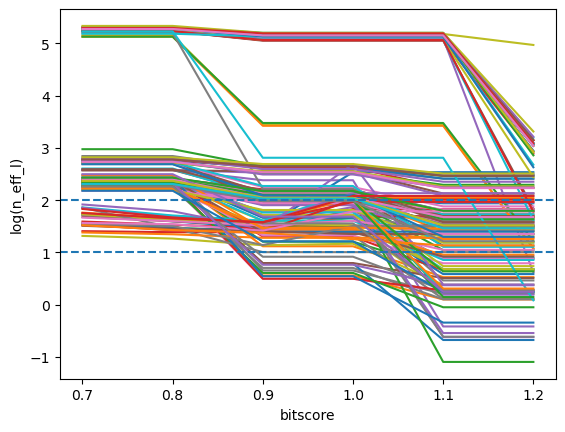

In [103]:
round3_aln_stats_pivot.fillna(method='ffill').apply(np.log10).plot.line(legend=False)
plt.axhline(1, linestyle='--')
plt.axhline(2, linestyle='--')
plt.ylabel('log(n_eff_l)')

/tmp/ipykernel_24013/150818962.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  subset_PF00096_seq_full.fillna(method='ffill').apply(np.log10).plot.line(legend=False)


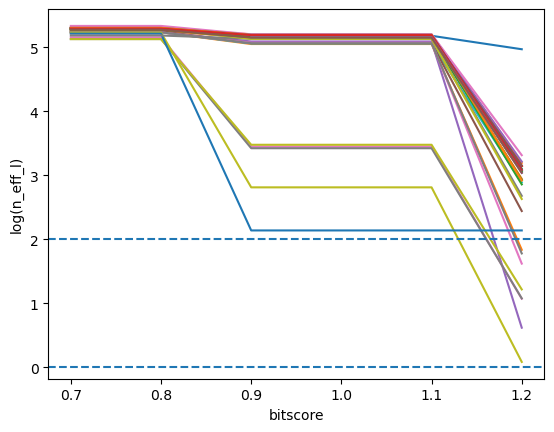

In [112]:
PF00096_seq_full_pivot = pd.concat([aln_stats_full, round3_aln_stats],
                             ignore_index=True, axis=0).drop_duplicates().pivot(index='bitscore', columns='protein', values='n_eff_l').filter(regex='_PF00096_')
non_nan_counts = PF00096_seq_full_pivot.notna().sum()
columns_to_keep = non_nan_counts[non_nan_counts > 1].index
subset_PF00096_seq_full = PF00096_seq_full_pivot[columns_to_keep]

subset_PF00096_seq_full.fillna(method='ffill').apply(np.log10).plot.line(legend=False)
plt.axhline(0, linestyle='--')
plt.axhline(2, linestyle='--')
plt.ylabel('log(n_eff_l)')
# plt.xticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.savefig('scripts/Beltran_Lehner_2025/Neff_L_bitscore_elbow_plot_PF00096_full.pdf')

#### Observation
1. large decrease in Neff/L at higher bitscores
2. For PF00096, work super well, still many with Neff/L in several hundreds, keep these and remove those with very high Neff/L (usually with >2M sequences) and keep the ones that are closest to 100
4. For others, keep the ones that are closest to 100
5. Don't filter based on minimum percent coverage

In [113]:
def find_bitscore_close_to_max_n_eff_l(df, max_n_eff_l=150):
    '''
    if the largest Neff_L < 150, take the largest one
    if the largest Neff_L > 150, take the one closest to 150
    '''
    if (df['n_eff_l']).all() > max_n_eff_l:
        best_row = df['n_eff_l'].idxmin()
    else:
        best_row = abs(df['n_eff_l'] - max_n_eff_l).idxmin()
    
    return df.loc[best_row]

def choose_best_bitscore_close_to_max_n_eff_l(df, max_num_seq=2000000, max_n_eff_l=150):
    df = df[df['num_seqs'] <= max_num_seq]
    return df.groupby('protein').apply(find_bitscore_close_to_max_n_eff_l)

#### Sanity check:
No overlap between round3 sequences and good sequences from above

In [121]:
round3_aln_stats['protein'].nunique()

160

In [122]:
higher_bitscore_run_df['protein'].nunique()

158

In [123]:
set(round3_aln_stats['protein'].tolist()) - set(higher_bitscore_run_df['protein'].tolist())

{'O75382_PF00643_111', 'Q9NQ86_PF00643_208'}

In [124]:
set(higher_bitscore_run_df['protein'].tolist()) - set(round3_aln_stats['protein'].tolist())

set()

In [125]:
round3_aln_stats[round3_aln_stats['protein'] == 'O75382_PF00643_111']

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
264,O75382_PF00643_111,16343,16360,0.998961,928.317075,21.098115,44,40,0.909091,0.9
371,O75382_PF00643_111,3828,3830,0.999478,56.678620,1.288150,44,44,1.000000,1.1


In [127]:
aln_stats_full[aln_stats_full['protein'] == 'O75382_PF00643_111']

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
49,O75382_PF00643_111,111282,111436,0.998618,6487.056465,147.433101,44,37,0.840909,0.7


**Bug fix:** Remove the sequences in round 3 that overlap with good sequences

**temporarily removing the ones rerunning at bitscore = 1.1**

In [139]:
good_round3_overlap = list(set(round3_aln_stats['protein'].tolist()) - set(higher_bitscore_run_df['protein'].tolist()))
round3_aln_stats = round3_aln_stats[~round3_aln_stats['protein'].isin(good_round3_overlap)]
round3_aln_stats = round3_aln_stats[~round3_aln_stats['protein'].isin(aws_rerun_list3)] # bitscore 1.1 rerun 6/22

In [140]:
round3_aln_stats_final_df = choose_best_bitscore_close_to_max_n_eff_l(round3_aln_stats)
round3_aln_stats_final_df

/tmp/ipykernel_24013/755361245.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('protein').apply(find_bitscore_close_to_max_n_eff_l)


,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
protein,,,,,,,,,,
A0PJY2_PF00096_289,A0PJY2_PF00096_289,1738850,1740971,0.998782,18757.110090,852.595913,22,21,0.954545,1.2
A1X283_PF00018_155,A1X283_PF00018_155,514408,514768,0.999301,14420.975246,262.199550,55,49,0.890909,0.7
A1X283_PF00018_222,A1X283_PF00018_222,503000,503356,0.999293,14439.386755,244.735369,59,50,0.847458,0.7
O00330_PF02817_181,O00330_PF02817_181,123402,123553,0.998778,11312.783619,240.697524,47,37,0.787234,0.9
O14901_PF00096_395,O14901_PF00096_395,100762,100808,0.999544,1645.216550,68.550690,24,21,0.875000,1.2
...,...,...,...,...,...,...,...,...,...,...
Q9Y2G7_PF00096_411,Q9Y2G7_PF00096_411,1908998,1911479,0.998702,23919.635048,1087.256139,22,21,0.954545,1.2
Q9Y462_PF00096_506,Q9Y462_PF00096_506,1866168,1868240,0.998891,24161.730654,1098.260484,22,21,0.954545,1.2
Q9Y5K6_PF00018_271,Q9Y5K6_PF00018_271,487664,487976,0.999361,12153.596273,199.239283,61,51,0.836066,0.7


In [141]:
round3_aln_stats_final_df['bitscore'].value_counts()

bitscore
0.9    47
0.7    42
1.2    34
1.1    15
1.0     2
Name: count, dtype: int64

In [142]:
set(round3_aln_stats['protein'].tolist()) - set(round3_aln_stats_final_df['protein'].tolist())

{'P37275_PF00096_933'}

In [143]:
set(round3_aln_stats_final_df['protein'].tolist()) - set(round3_aln_stats['protein'].tolist())

set()

In [144]:
round3_aln_stats[round3_aln_stats['protein'] == 'P37275_PF00096_933']

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
46,P37275_PF00096_933,4286191,4291470,0.998770,4286191.0,194826.863636,22,21,0.954545,0.7
171,P37275_PF00096_933,3330443,3334767,0.998703,3330443.0,151383.772727,22,21,0.954545,0.9
479,P37275_PF00096_933,2052531,2055160,0.998721,2052531.0,93296.863636,22,21,0.954545,1.2


#### Summary:
1. P37275_PF00096_933 is filtered out because alignments have over 2M sequences
2. Currently, filtered out overlaps in round 3 with the good sequences and the sequences rerun at bitscore=1.1 (a bug previously)

In [145]:
round3_aln_stats_final_df.to_csv("output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_rerun_round3_aln_stats.csv", index=False)

### Visualize the alignments where perc_cov went down with higher bitscores
1. For `P46937_PF00397_162` and 10 others

## Summary

Add the two manually include sequences to all the sequences that have been optimized for bitscore runs

In [155]:
manually_add_df = aln_stats_full.loc[(aln_stats_full['protein'].isin(['EHEE-rd1-0882_rockdoms_1', 'Q9NYL2_PF00536_330'])) & (aln_stats_full['bitscore'] == 0.5)]
final_df = pd.concat([aln_stats_good_bitscore, round3_aln_stats_final_df, low_n_eff_l_df, manually_add_df], 
                     ignore_index=True, axis=0).sort_values(by=['protein'])

In [157]:
final_df['protein'].value_counts()

protein
Q9Y6V0_PF05715_1058     1
A0A2R8Y422_PF00240_2    1
A0PJY2_PF00096_289      1
A1X283_PF00018_155      1
A1X283_PF00018_222      1
                       ..
O15350_PF07647_487      1
O15405_PF00505_256      1
O15541_PF00642_198      1
O43167_PF00096_351      1
O43167_PF00096_435      1
Name: count, Length: 503, dtype: int64

503/522 sequences have usable .m2a output: 
- 1 sequence has a very high Neff/L
- 1 sequence (design sequence from Rocklin) has no other sequence aligned to it at bitscore=0.5
- 17 are being rerun at higher bitscore

In [198]:
final_df.to_csv("output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_3round_Jun22_aln_stats.csv", index=False)

# Come back to this after running the models

In [11]:
final_df = pd.read_csv('output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_3round_Jun22_aln_stats.csv')

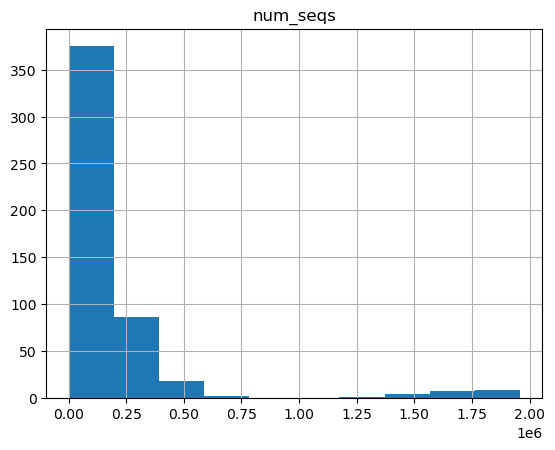

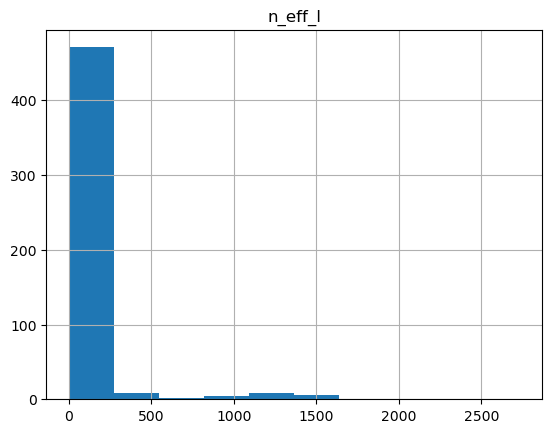

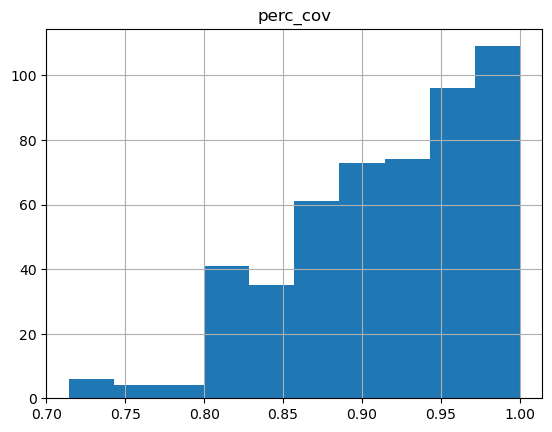

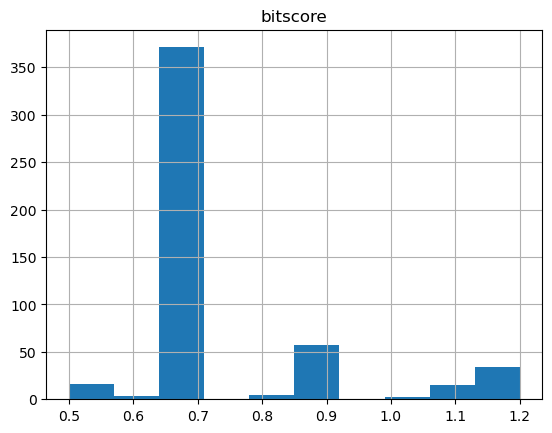

In [158]:
final_df.hist(column='num_seqs')
plt.savefig('scripts/Beltran_Lehner_2025/Domainome_503_num_seqs.pdf')
final_df.hist(column='n_eff_l')
plt.savefig('scripts/Beltran_Lehner_2025/Domainome_503_neff_l.pdf')
final_df.hist(column='perc_cov')
plt.savefig('scripts/Beltran_Lehner_2025/Domainome_503_perc_cov.pdf')
final_df.hist(column='bitscore')
plt.savefig('scripts/Beltran_Lehner_2025/Domainome_503_bitscore.pdf')
plt.show()

In [159]:
final_df.describe()

,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
count,5.030000e+02,5.030000e+02,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000
mean,1.809384e+05,1.811438e+05,0.998434,4807.793657,125.123286,58.113320,53.401590,0.915896,0.763618
std,3.541687e+05,3.545204e+05,0.001960,7718.681737,280.350066,18.931442,18.267429,0.061908,0.154895
min,1.189000e+03,1.194000e+03,0.973684,15.847524,0.205812,19.000000,15.000000,0.714286,0.500000
25%,1.604850e+04,1.606950e+04,0.997910,465.112264,7.756774,45.000000,39.500000,0.876868,0.700000
50%,5.692200e+04,5.699900e+04,0.999061,2872.453202,43.603156,59.000000,54.000000,0.924051,0.700000
75%,2.073915e+05,2.076915e+05,0.999410,6197.954734,114.496696,71.500000,67.000000,0.966102,0.700000
max,1.957621e+06,1.959971e+06,1.000000,109295.701468,2732.392537,97.000000,94.000000,1.000000,1.200000


### Data cleaning and storage

1. Download the weights and move the .a2m files at the selected bitscore for each sample
2. Convert the naming to Swiss-Prot (see [notebook](/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/notebooks_assays/Beltran_Lehner_2025.ipynb) for more details)
3. Output the reference sheet covering all MSA proportions

Need to compile the following columns: 
- MSA_filename
- MSA_start
- MSA_end
- MSA_len
- MSA_bitscore
- MSA_theta = 0.2
- MSA_num_seqs
- MSA_perc_cov
- MSA_num_cov
- MSA_N_eff
- MSA_Neff_L
- MSA_Neff_L_category
- weight_file_name

In [17]:
idmapping_csv = '/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/processed_data/Beltran_Lehner_2025/idmapping_2025_06_10.csv'
with open(idmapping_csv, mode='r') as f_in:
    reader = csv.reader(f_in)
    idmapping_dict = {rows[0]:rows[1] for rows in reader}

copied from [EVE github](https://github.com/aaronkollasch/EVE/blob/master/scripts/get_alignment_stats.py)

In [4]:
@contextmanager
def suppress_stdout_stderr():
    """A context manager that redirects stdout and stderr to devnull"""
    with open(os.devnull, 'w') as fnull:
        with redirect_stderr(fnull) as err, redirect_stdout(fnull) as out:
            yield (err, out)

def s3_cp_file(from_path, to_path, silent=False):
    max_runs = 3
    run = 0
    error = Exception()
    while run < max_runs:
        try:
            return subprocess.run(
                ["aws", "s3", "cp", from_path, to_path],
                check=True,
                stdout=subprocess.DEVNULL if silent else None,
                stderr=subprocess.DEVNULL if silent else None,
            )
        except subprocess.CalledProcessError as e:
            error = e
            continue
        else:
            break
        finally:
            run += 1
    else:
        raise error

In [14]:
def cp_file(from_path, to_path, silent=False):
    try:
        return subprocess.run(
            ["cp", from_path, to_path],
            check=True,
            stdout=subprocess.DEVNULL if silent else None,
            stderr=subprocess.DEVNULL if silent else None,
        )
    except subprocess.CalledProcessError as e:
        raise e


def label_neff_l(row):
    if row['n_eff_l'] < 1:
        return 'low'
    elif row['n_eff_l'] >= 1 and row['n_eff_l'] < 100:
        return 'medium'
    else:
        return 'high'

In [17]:
def download_weights_move_msa(
        final_df, 
        idmapping_dict, 
        aws_weights_dir="s3://markslab-private/eve/beltran_domains/data/weights/beltran_domains_jackhmmer_bitscore_", 
        o2_weights_dir="output/Beltran_Lehner_2025/weights/", 
        o2_original_a2m_dir="output/Beltran_Lehner_2025/uniref100/", 
        o2_a2m_dir="output/Beltran_Lehner_2025/selected_alignments/",
        o2_model_dir="output/Beltran_Lehner_2025/selected_models/"
    ):
    os.makedirs(o2_weights_dir, exist_ok=True)
    os.makedirs(o2_a2m_dir, exist_ok=True)
    os.makedirs(o2_model_dir, exist_ok=True)

    index_list, dms_id_list, msa_filename_list, weight_filename_list, model_filename_list = [], [], [], [], []
    
    for _, row in final_df.iterrows():
        index = row['protein']
        protein, domain, idx = index.split('_')
        if protein in idmapping_dict:
            n = 0 # only sequences that have ALL files successfully downloaded are added to the output df 
            dms_id = "_".join([idmapping_dict[protein], "Beltran_2025", domain, idx])
            bitscore = str(row['bitscore'])
            if bitscore == '1.0':
                bitscore = '1'
    
            # download weight
            try:
                aws_weight_file = f"{aws_weights_dir}{bitscore}/{index}_bit_{bitscore}_theta_0.8_colcov_0.npy"
                o2_weight_file = f"{o2_weights_dir}{dms_id}_theta_0.8_b{bitscore}.npy"
                # s3_cp_file(aws_weight_file, o2_weight_file)
                n += 1
            except subprocess.CalledProcessError:
                continue
    
            # move and rename msa
            try:
                old_msa_filename = f"{o2_original_a2m_dir}/{index}/{index}_bit_{bitscore}_theta_0.8_colcov_0/align/{index}_bit_{bitscore}_theta_0.8_colcov_0.a2m"
                new_msa_filename = o2_a2m_dir + "_".join([dms_id, "theta_0.8", f"b{bitscore}.a2m"])
                # cp_file(old_msa_filename, new_msa_filename)
                n += 1
            except subprocess.CalledProcessError:
                continue
    
            # move and rename couplings model file
            try:
                old_model_filename = f"{o2_original_a2m_dir}/{index}/{index}_bit_{bitscore}_theta_0.8_colcov_0/couplings/{index}_bit_{bitscore}_theta_0.8_colcov_0.model"
                new_model_filename = o2_model_dir + "_".join([dms_id, f"b{bitscore}.model"])
                # cp_file(old_model_filename, new_model_filename)
                n += 1
            except subprocess.CalledProcessError:
                continue

            if n == 3: # was 3
                index_list.append(index)
                dms_id_list.append(dms_id)
                weight_filename_list.append(basename(o2_weight_file))
                msa_filename_list.append(basename(new_msa_filename))
                model_filename_list.append(basename(new_model_filename))
        else:
            print(f"{protein} is not in the idmapping directory")

    file_dict = {
        'protein': index_list, 
        'DMS_id': dms_id_list, 
        'weight_file_name': weight_filename_list,
        'MSA_filename': msa_filename_list, 
        'EVCouplings_model_filename': model_filename_list
    }
    file_df = pd.DataFrame(file_dict)
    
    return file_df

In [41]:
def merge_file_final_df(file_df, final_df, target_seq_df):
    final_df['perc_cov'] = np.round(final_df['perc_cov'], 3)
    final_df['n_eff'] = np.round(final_df['n_eff'], 1)
    final_df['MSA_Neff_L_category'] = final_df.apply(label_neff_l, axis=1)

    merged_df = file_df.merge(final_df, left_on='protein', right_on='protein')
    merged_df = merged_df[['DMS_id', 
                           'bitscore', 'num_seqs_unfiltered', 
                           'perc_cov', 'num_cov',
                           'n_eff', 'n_eff_l', 'MSA_Neff_L_category', 
                           'weight_file_name',
                           'MSA_filename', 'EVCouplings_model_filename'
                          ]]
    merged_df.rename(
        columns={
            'bitscore': 'MSA_bitscore',
            'num_seqs_unfiltered': 'MSA_num_seqs',
            'perc_cov': 'MSA_perc_cov',
            'num_cov': 'MSA_num_cov',
            'n_eff': 'MSA_N_eff',
            'n_eff_l': 'MSA_Neff_L',
        }, 
        inplace=True)
    
    merged_df = merged_df.merge(target_seq_df, left_on='DMS_id', right_on='DMS_id')
    merged_df['DMS_filename'] = merged_df['DMS_id'].apply(lambda x: x + '.csv')
    merged_df['offset'] = merged_df['DMS_id'].apply(lambda x: x.split('_')[-1])
    merged_df['seq_len'] = merged_df['target_aa_seq'].apply(lambda x: len(x))
    merged_df['pdb_file'] = merged_df.apply(lambda row: row.DMS_id + '.pdb', axis=1)
    merged_df['UniProt_ID'] = merged_df['DMS_id'].apply(lambda x: "_".join(x.split('_')[:2]))

    return merged_df

change this below

In [38]:
def add_MSA_0_colcov_info(
        merged_df,
        idmapping_dict,
        evcouplings_output_dir="output/Beltran_Lehner_2025/uniref100/",
    ):
    index_list, seqlen_list, msa_start_list, msa_end_list = [], [], [], []
    reversed_idmapping_dict = {value: key for key, value in idmapping_dict.items()}
    
    for index, row in merged_df.iterrows():
        sample_id = "_".join([reversed_idmapping_dict[row['UniProt_ID']], row['DMS_id'].split("_")[4], row['DMS_id'].split("_")[5]])
        summary_csv = evcouplings_output_dir + \
            "_".join([f"{sample_id}/{sample_id}_bit_{row['MSA_bitscore']}", "theta_0.8_colcov_0_job_statistics_summary.csv"])
        if str(row['MSA_bitscore']) == '1.0':
            try:
                df = pd.read_csv(summary_csv)
            except FileNotFoundError:
                summary_csv = evcouplings_output_dir + \
                              "_".join([f"{sample_id}/{sample_id}_bit_1", "theta_0.8_colcov_0_job_statistics_summary.csv"])
        elif str(row['MSA_bitscore']) == '1':
            try:
                df = pd.read_csv(summary_csv)
            except FileNotFoundError:
                summary_csv = evcouplings_output_dir + \
                              "_".join([f"{sample_id}/{sample_id}_bit_1.0", "theta_0.8_colcov_0_job_statistics_summary.csv"])

        df = pd.read_csv(summary_csv)
        index_list.append(index)
        seqlen_list.append(df['seqlen'][0])
        msa_start_list.append(df['1st_uc'][0])
        msa_end_list.append(df['last_uc'][0])

    add_col_df = pd.DataFrame({'index': index_list,
                               'MSA_start': msa_start_list,
                               'MSA_end': msa_end_list,
                               'MSA_len': seqlen_list})
    add_col_df = add_col_df.set_index('index')

    msa_df = merged_df.merge(add_col_df, left_index=True, right_index=True)

    return msa_df

In [9]:
os.chdir("/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/EVCouplings")

In [10]:
file_df = download_weights_move_msa(final_df, idmapping_dict)
file_df.to_csv("output/Beltran_Lehner_2025/beltran_domains_jackhmmer_3round_Jun22_file.csv", index=False)

NameError: name 'final_df' is not defined

In [35]:
file_df = pd.read_csv("output/Beltran_Lehner_2025/beltran_domains_jackhmmer_3round_Jun22_file.csv")

In [36]:
file_df

,protein,DMS_id,MSA_filename,EVCouplings_model_filename
0,A0A2R8Y422_PF00240_2,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2_b0.7.a2m,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2_b0.7.m...
1,A0PJY2_PF00096_289,FEZF1_HUMAN_Beltran_2025_PF00096_289,FEZF1_HUMAN_Beltran_2025_PF00096_289_b1.2.a2m,FEZF1_HUMAN_Beltran_2025_PF00096_289_b1.2.model
2,A1X283_PF00018_155,SPD2B_HUMAN_Beltran_2025_PF00018_155,SPD2B_HUMAN_Beltran_2025_PF00018_155_b0.7.a2m,SPD2B_HUMAN_Beltran_2025_PF00018_155_b0.7.model
3,A2RRE5_PF01846_267,A2RRE5_HUMAN_Beltran_2025_PF01846_267,A2RRE5_HUMAN_Beltran_2025_PF01846_267_b0.7.a2m,A2RRE5_HUMAN_Beltran_2025_PF01846_267_b0.7.model
4,A6NK59_PF07525_532,ASB14_HUMAN_Beltran_2025_PF07525_532,ASB14_HUMAN_Beltran_2025_PF07525_532_b0.7.a2m,ASB14_HUMAN_Beltran_2025_PF07525_532_b0.7.model
...,...,...,...,...
495,Q9Y5K6_PF14604_1,CD2AP_HUMAN_Beltran_2025_PF14604_1,CD2AP_HUMAN_Beltran_2025_PF14604_1_b0.9.a2m,CD2AP_HUMAN_Beltran_2025_PF14604_1_b0.9.model
496,Q9Y5K6_PF14604_109,CD2AP_HUMAN_Beltran_2025_PF14604_109,CD2AP_HUMAN_Beltran_2025_PF14604_109_b0.9.a2m,CD2AP_HUMAN_Beltran_2025_PF14604_109_b0.9.model
497,Q9Y618_PF00249_613,NCOR2_HUMAN_Beltran_2025_PF00249_613,NCOR2_HUMAN_Beltran_2025_PF00249_613_b0.7.a2m,NCOR2_HUMAN_Beltran_2025_PF00249_613_b0.7.model
498,Q9Y6N9_PF00595_207,USH1C_HUMAN_Beltran_2025_PF00595_207,USH1C_HUMAN_Beltran_2025_PF00595_207_b0.7.a2m,USH1C_HUMAN_Beltran_2025_PF00595_207_b0.7.model


In [42]:
target_seq_df = pd.read_csv('output/Beltran_Lehner_2025/target_seq.csv')
target_seq_df

,DMS_id,target_aa_seq
0,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2,QIFVKTLMGKTITLEVELSDTIDNVKAKIQDKEGIPPDQQRLIFAG...
1,FEZF1_HUMAN_Beltran_2025_PF00096_289,VCKVCGKGFRQASTLCRHKIIH
2,SPD2B_HUMAN_Beltran_2025_PF00018_155,EQYVVVANYQKQESSEISLSVGQVVDIIEKNESGWWFVSTAEEQGW...
3,SPD2B_HUMAN_Beltran_2025_PF00018_222,EEEKYTVIYPYTARDQDEMNLERGAVVEVIQKNLEGWWKIRYQGKE...
4,A2RRE5_HUMAN_Beltran_2025_PF01846_267,SQQIATAKDKYEWLVSRIVKNHNENWLSVSRKMQASPEYQDYVYLE...
...,...,...
517,CD2AP_HUMAN_Beltran_2025_PF14604_1,MVDYIVEYDYDAVHDDELTIRVGEIIRNVKKLQEEGWLEGELNGRR...
518,CD2AP_HUMAN_Beltran_2025_PF14604_109,KKRQCKVLFEYIPQNEDELELKVGDIIDINEEVEEGWWSGTLNNKL...
519,NCOR2_HUMAN_Beltran_2025_PF00249_613,SRWTEEEMETAKKGLLEHGRNWSAIARMVGSKTVSQCKNFYFNYKK...
520,USH1C_HUMAN_Beltran_2025_PF00595_207,NKEKKVFISLVGSRGLGCSISSGPIQKPGIFISHVKPGSLSAEVGL...


In [41]:
merged_df = merge_file_final_df(file_df, final_df, target_seq_df)

In [49]:
merged_df

,DMS_id,MSA_bitscore,MSA_num_seqs,MSA_perc_cov,MSA_num_cov,MSA_N_eff,MSA_Neff_L,MSA_Neff_L_category,MSA_filename,EVCouplings_model_filename,target_seq,DMS_filename,offset,seq_len
0,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2,0.7,61559,0.971,68,5929.1,84.701140,medium,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2_b0.7.a2m,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2_b0.7.m...,QIFVKTLMGKTITLEVELSDTIDNVKAKIQDKEGIPPDQQRLIFAG...,A0A2R8Y422_HUMAN_Beltran_2025_PF00240_2.csv,2,70
1,FEZF1_HUMAN_Beltran_2025_PF00096_289,1.2,1740971,0.955,21,18757.1,852.595913,high,FEZF1_HUMAN_Beltran_2025_PF00096_289_b1.2.a2m,FEZF1_HUMAN_Beltran_2025_PF00096_289_b1.2.model,VCKVCGKGFRQASTLCRHKIIH,FEZF1_HUMAN_Beltran_2025_PF00096_289.csv,289,22
2,SPD2B_HUMAN_Beltran_2025_PF00018_155,0.7,514768,0.891,49,14421.0,262.199550,high,SPD2B_HUMAN_Beltran_2025_PF00018_155_b0.7.a2m,SPD2B_HUMAN_Beltran_2025_PF00018_155_b0.7.model,EQYVVVANYQKQESSEISLSVGQVVDIIEKNESGWWFVSTAEEQGW...,SPD2B_HUMAN_Beltran_2025_PF00018_155.csv,155,55
3,SPD2B_HUMAN_Beltran_2025_PF00018_222,0.7,503356,0.847,50,14439.4,244.735369,high,SPD2B_HUMAN_Beltran_2025_PF00018_222_b0.7.a2m,SPD2B_HUMAN_Beltran_2025_PF00018_222_b0.7.model,EEEKYTVIYPYTARDQDEMNLERGAVVEVIQKNLEGWWKIRYQGKE...,SPD2B_HUMAN_Beltran_2025_PF00018_222.csv,222,59
4,A2RRE5_HUMAN_Beltran_2025_PF01846_267,0.7,4543,0.952,60,128.7,2.042930,medium,A2RRE5_HUMAN_Beltran_2025_PF01846_267_b0.7.a2m,A2RRE5_HUMAN_Beltran_2025_PF01846_267_b0.7.model,SQQIATAKDKYEWLVSRIVKNHNENWLSVSRKMQASPEYQDYVYLE...,A2RRE5_HUMAN_Beltran_2025_PF01846_267.csv,267,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,CD2AP_HUMAN_Beltran_2025_PF14604_1,0.9,275128,0.864,51,6534.3,110.750279,high,CD2AP_HUMAN_Beltran_2025_PF14604_1_b0.9.a2m,CD2AP_HUMAN_Beltran_2025_PF14604_1_b0.9.model,MVDYIVEYDYDAVHDDELTIRVGEIIRNVKKLQEEGWLEGELNGRR...,CD2AP_HUMAN_Beltran_2025_PF14604_1.csv,1,59
497,CD2AP_HUMAN_Beltran_2025_PF14604_109,0.9,263728,0.869,53,6540.0,107.212910,high,CD2AP_HUMAN_Beltran_2025_PF14604_109_b0.9.a2m,CD2AP_HUMAN_Beltran_2025_PF14604_109_b0.9.model,KKRQCKVLFEYIPQNEDELELKVGDIIDINEEVEEGWWSGTLNNKL...,CD2AP_HUMAN_Beltran_2025_PF14604_109.csv,109,61
498,NCOR2_HUMAN_Beltran_2025_PF00249_613,0.7,57518,0.828,48,1467.9,25.307762,medium,NCOR2_HUMAN_Beltran_2025_PF00249_613_b0.7.a2m,NCOR2_HUMAN_Beltran_2025_PF00249_613_b0.7.model,SRWTEEEMETAKKGLLEHGRNWSAIARMVGSKTVSQCKNFYFNYKK...,NCOR2_HUMAN_Beltran_2025_PF00249_613.csv,613,58
499,USH1C_HUMAN_Beltran_2025_PF00595_207,0.7,123337,0.831,74,1477.5,16.601235,medium,USH1C_HUMAN_Beltran_2025_PF00595_207_b0.7.a2m,USH1C_HUMAN_Beltran_2025_PF00595_207_b0.7.model,NKEKKVFISLVGSRGLGCSISSGPIQKPGIFISHVKPGSLSAEVGL...,USH1C_HUMAN_Beltran_2025_PF00595_207.csv,207,89


In [50]:
merged_df.to_csv("output/Beltran_Lehner_2025/temp_ref_file.csv", index=False)

## To run a quick EVmutation scoring, produce the following files
- temporary DMS reference file: DMS_id, DMS_filename
- DMS a2m folder
- model folder
- scores folder

## Compare the alignment statistics with PG1 and the dataset collected for the viral family paper

can plot Human - seq_len, MSA_num_seqs, MSA_perc_cov, MSA_bitscore, MSA_Neff_L

In [5]:
ref_file = '/n/groups/marks/projects/marks_lab_and_oatml/ProteinGym2/DMS_assays/notebooks/DMS_substitutions.csv'
df_ref = pd.read_csv(ref_file)
df_ref.head()

,DMS_index,DMS_id,DMS_filename,UniProt_ID,taxon,source_organism,target_seq,seq_len,includes_multiple_mutants,DMS_total_number_mutants,...,raw_DMS_filename,raw_DMS_phenotype_name,raw_DMS_directionality,raw_DMS_mutant_column,weight_file_name,pdb_file,pdb_range,ProteinGym_version,raw_mut_offset,coarse_selection_type
0,DMS_sub_0,A0A140D2T1_ZIKV_Sourisseau_2019,A0A140D2T1_ZIKV_Sourisseau_2019.csv,A0A140D2T1_ZIKV,Virus,Zika virus (ZIKV),MKNPKKKSGGFRIVNMLKRGVARVNPLGGLKRLPAGLLLGHGPIRM...,3423,False,9576,...,A0A140D2T1_ZIKV_Sourisseau_growth_2019.csv,effect,1,mutant,A0A140D2T1_ZIKV_theta_0.01.npy,A0A140D2T1_ZIKV.pdb,291-794,0.1,NaN,OrganismalFitness
1,DMS_sub_1,A0A192B1T2_9HIV1_Haddox_2018,A0A192B1T2_9HIV1_Haddox_2018.csv,A0A192B1T2_9HIV1,Virus,Human immunodeficiency virus 1,MRVKGIQMNSQHLLRWGIMILGMIMICSVAGNLWVTVYYGVPVWKD...,852,False,12577,...,A0A192B1T2_9HIV1_Haddox_2018.csv,fitness,1,mutant,A0A192B1T2_9HIV1_theta_0.01.npy,A0A192B1T2_9HIV1.pdb,1-852,0.1,NaN,OrganismalFitness
2,DMS_sub_2,A0A1I9GEU1_NEIME_Kennouche_2019,A0A1I9GEU1_NEIME_Kennouche_2019.csv,A0A1I9GEU1_NEIME,Prokaryote,Neisseria meningitidis,FTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSA...,161,False,922,...,A0A1I9GEU1_NEIME_Kennouche_2019.csv,piliation_log2_ratio,1,mutants,A0A1I9GEU1_NEIME_theta_0.2.npy,A0A1I9GEU1_NEIME.pdb,1-161,0.1,NaN,Activity
3,DMS_sub_3,A0A247D711_LISMN_Stadelmann_2021,A0A247D711_LISMN_Stadelmann_2021.csv,A0A247D711_LISMN,Prokaryote,Listeria monocytogenes,MNINDLIREIKNKDYTVKLSGTDSNSITQLIIRVNNDGNEYVISES...,87,False,1653,...,A0A247D711_LISMN_Stadelmann_2021.csv,mean_prediction,1,mutant,A0A247D711_LISMN_b03_theta_0.2.npy,A0A247D711_LISMN.pdb,1-87,1.0,NaN,Activity
4,DMS_sub_4,A0A2Z5U3Z0_9INFA_Doud_2016,A0A2Z5U3Z0_9INFA_Doud_2016.csv,A0A2Z5U3Z0_9INFA,Virus,Influenza A virus (A/WSN/1933(H1N1)),MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,565,False,10715,...,A0A2Z5U3Z0_9INFA_Doud_2016.csv,transformed_pref,1,mutant,A0A2Z5U3Z0_9INFA_theta_0.01.npy,A0A2Z5U3Z0_9INFA.pdb,1-565,0.1,NaN,OrganismalFitness


In [47]:
df_ref.columns

Index(['DMS_index', 'DMS_id', 'DMS_filename', 'UniProt_ID', 'taxon',
       'source_organism', 'target_seq', 'seq_len', 'includes_multiple_mutants',
       'DMS_total_number_mutants', 'DMS_number_single_mutants',
       'DMS_number_multiple_mutants', 'DMS_binarization_cutoff',
       'DMS_binarization_method', 'first_author', 'title', 'year', 'jo',
       'region_mutated', 'molecule_name', 'selection_assay', 'selection_type',
       'MSA_filename', 'MSA_start', 'MSA_end', 'MSA_len', 'MSA_bitscore',
       'MSA_theta', 'MSA_num_seqs', 'MSA_perc_cov', 'MSA_num_cov', 'MSA_N_eff',
       'MSA_Neff_L', 'MSA_Neff_L_category', 'MSA_num_significant',
       'MSA_num_significant_L', 'raw_DMS_filename', 'raw_DMS_phenotype_name',
       'raw_DMS_directionality', 'raw_DMS_mutant_column', 'weight_file_name',
       'pdb_file', 'pdb_range', 'ProteinGym_version', 'raw_mut_offset',
       'coarse_selection_type'],
      dtype='object')

can plot neff_L, Num_Seq

In [4]:
virus_file = 'scripts/Beltran_Lehner_2025/selected_alignments_across_viruses_final.csv'
virus_df_ref = pd.read_csv(virus_file)
virus_df_ref.head()

,Unnamed: 0,DMS ID,model,bitscore,database,log_neff90,Num_Seq,Prop_90,Len_Seq,Neff90,num_seq_log,Neff,neff_L,neff_L_log,Neff90_L,Neff90_L_log,prop_90_neff_min,EVH_Spearman,PSSM_Spearman,EVE_Spearman
0,0,A0A192B1T2_9HIV1_Haddox_2018,prediction_epistatic_b.1_uniref90,0.1,uniref90,0.003399,22856,0.001181,852,18.098413,10.036969,17469.4,20.503991,1.311838,0.021242,-1.672799,0.001181,0.407655,0.493088,0.475617
1,1,A0A2Z5U3Z0_9INFA_Doud_2016,prediction_epistatic_b.5_uniref90,0.5,uniref90,0.002849,1551,0.003224,565,5.000000,7.346655,1161.8,2.056283,0.313083,0.008850,-2.053078,0.003224,0.388975,0.397996,0.490663
2,2,A0A2Z5U3Z0_9INFA_Wu_2014,prediction_epistatic_b.5_uniref90,0.5,uniref90,0.002849,1551,0.003224,565,5.000000,7.346655,1161.8,2.056283,0.313083,0.008850,-2.053078,0.003224,0.378476,0.379568,0.421867
3,3,A4D664_9INFA_Soh_2019,prediction_epistatic_b.5_uniref100,0.5,uniref100,0.009955,29525,0.913531,759,1911.674655,10.292993,2040.8,2.688801,0.429559,2.518675,0.401172,0.913531,0.242970,0.407326,0.419352
4,4,C6KNH7_9INFA_Lee_2018,prediction_epistatic_b.5_uniref100,0.5,uniref100,0.011534,72624,0.158584,566,684.221237,11.193051,14174.7,25.043640,1.398697,1.208871,0.082380,0.158584,0.379501,0.396826,0.408516


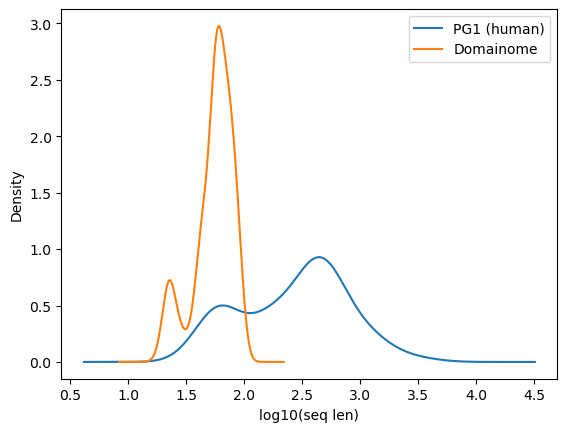

In [60]:
df_ref_human = df_ref[df_ref['taxon'] == 'Human']
axe = df_ref_human['seq_len'].apply(np.log10).plot.density(label='PG1 (human)')
merged_df['seq_len'].apply(np.log10).plot.density(ax=axe, label='Domainome')
axe.set_xlabel("log10(seq len)")
axe.legend()
plt.savefig('scripts/Beltran_Lehner_2025/PG1_domainome_seq_len.pdf')

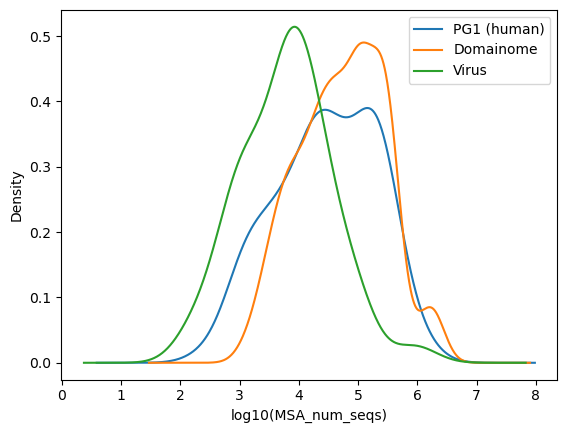

In [74]:
axe = df_ref_human['MSA_num_seqs'].apply(np.log10).plot.density(label='PG1 (human)')
merged_df['MSA_num_seqs'].apply(np.log10).plot.density(ax=axe, label='Domainome')
virus_df_ref['Num_Seq'].apply(np.log10).plot.density(ax=axe, label='Virus')
axe.set_xlabel("log10(MSA_num_seqs)")
axe.legend()
plt.savefig('scripts/Beltran_Lehner_2025/PG1_domainome_virus_MSA_num_seqs.pdf')

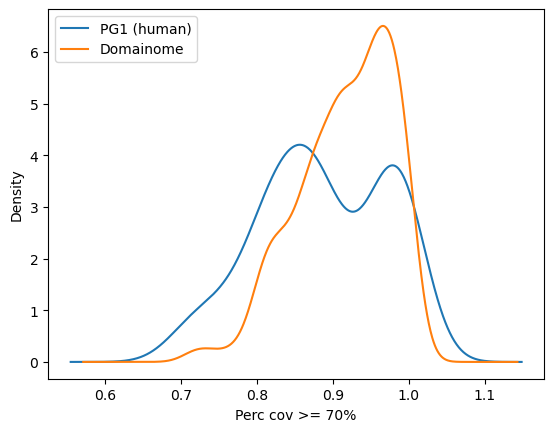

In [68]:
axe = df_ref_human['MSA_perc_cov'].plot.density(label='PG1 (human)')
merged_df['MSA_perc_cov'].plot.density(ax=axe, label='Domainome')
axe.set_xlabel("Perc cov >= 70%")
axe.legend()
plt.savefig('scripts/Beltran_Lehner_2025/PG1_domainome_MSA_perc_cov.pdf')

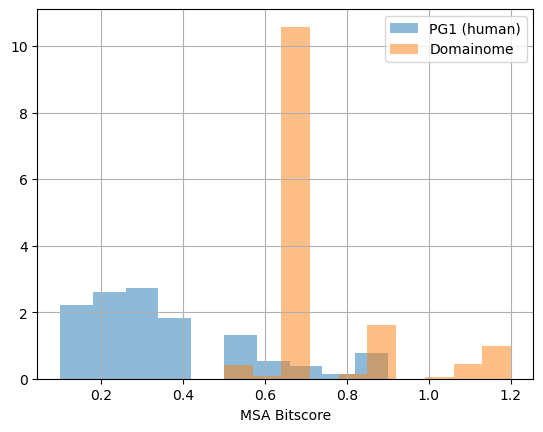

In [72]:
axe = df_ref_human['MSA_bitscore'].hist(density=True, alpha=0.5, label='PG1 (human)')
merged_df['MSA_bitscore'].hist(ax=axe, density=True, alpha=0.5, label='Domainome')
axe.set_xlabel("MSA Bitscore")
axe.legend()
plt.savefig('scripts/Beltran_Lehner_2025/PG1_domainome_MSA_bitscore.pdf')

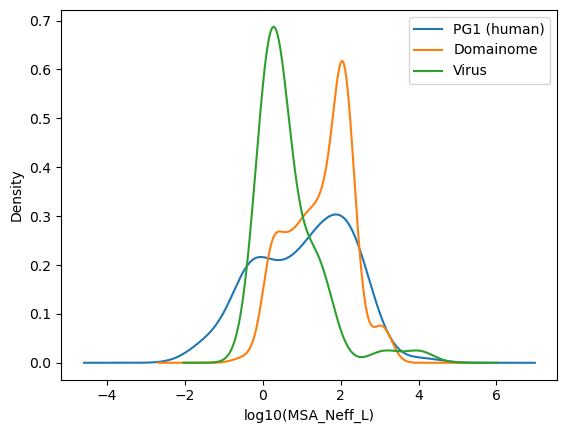

In [75]:
axe = df_ref_human['MSA_Neff_L'].apply(np.log10).plot.density(label='PG1 (human)')
merged_df['MSA_Neff_L'].apply(np.log10).plot.density(ax=axe, label='Domainome')
virus_df_ref['neff_L'].apply(np.log10).plot.density(ax=axe, label='Virus')
axe.set_xlabel("log10(MSA_Neff_L)")
axe.legend()
plt.savefig('scripts/Beltran_Lehner_2025/PG1_domainome_virus_MSA_Neff_L.pdf')

In [65]:
df_ref_human['DMS_id'].str.contains('Tsuboyama').sum()

np.int64(22)

In [66]:
df_ref_human['DMS_id']

6                      A4_HUMAN_Seuma_2022
10                    ACE2_HUMAN_Chan_2020
11                  ADRB2_HUMAN_Jones_2020
12         AICDA_HUMAN_Gajula_2014_3cycles
13          AMFR_HUMAN_Tsuboyama_2023_4G3O
                      ...                 
206        UBE4B_HUMAN_Tsuboyama_2023_3L1X
208         UBR5_HUMAN_Tsuboyama_2023_1I2T
211    VKOR1_HUMAN_Chiasson_2020_abundance
212     VKOR1_HUMAN_Chiasson_2020_activity
215                  YAP1_HUMAN_Araya_2012
Name: DMS_id, Length: 96, dtype: object

## Finalize criteria to choose the best MSA based on Neff/L and percentage coverage (7/10/2025)

In [25]:
prefix = 'beltran_domains_jackhmmer_bitscore_'
full_df_list = []
for aln_stats_f in glob("./output/Beltran_Lehner_2025/aln_stats/*_bitscore_*_aln_stats.csv"):
    df = pd.read_csv(aln_stats_f)
    bitscore = float(basename(aln_stats_f).removeprefix(prefix).split("_")[0])
    df['bitscore'] = bitscore
    full_df_list.append(df)
full_df = pd.concat(full_df_list, ignore_index=True, axis=0).sort_values(by=['protein', 'bitscore'])

In [26]:
full_df

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
42,A0A2R8Y422_PF00240_2,61139,61559,0.993177,5.929080e+03,84.701140,70,68,0.971429,0.7
43,A0PJY2_PF00096_289,4082271,4087406,0.998744,4.082271e+06,185557.772727,22,21,0.954545,0.7
604,A0PJY2_PF00096_289,3092510,3096441,0.998730,3.092510e+06,140568.636364,22,21,0.954545,0.9
903,A0PJY2_PF00096_289,1738850,1740971,0.998782,1.875711e+04,852.595913,22,21,0.954545,1.2
44,A1X283_PF00018_155,514408,514768,0.999301,1.442098e+04,262.199550,55,49,0.890909,0.7
...,...,...,...,...,...,...,...,...,...,...
777,Q9Y5K6_PF14604_109,263559,263728,0.999359,6.539988e+03,107.212910,61,53,0.868852,0.9
902,Q9Y5K6_PF14604_109,101884,101933,0.999519,1.764578e+03,28.927503,61,53,0.868852,1.1
556,Q9Y618_PF00249_613,57496,57518,0.999618,1.467850e+03,25.307762,58,48,0.827586,0.7
557,Q9Y6N9_PF00595_207,123241,123337,0.999222,1.477510e+03,16.601235,89,74,0.831461,0.7


In [8]:
max_n_eff_l = 100
min_n_eff_l = 1
min_num_seq = 100
min_perc_cov = 0.7

In [9]:
def good_run_condition_new(x, max_n_eff_l=max_n_eff_l, min_n_eff_l=min_n_eff_l, min_num_seq=min_num_seq, min_perc_cov=min_perc_cov):
    return (((x['n_eff_l'] <= max_n_eff_l) & (x['n_eff_l'] >= min_n_eff_l)) & (x['num_seqs'] >= min_num_seq) & (np.round(x['perc_cov'], 2) >= min_perc_cov)).any()

def rerun_higher_bitscore_condition_new(x, 
                                        max_n_eff_l=max_n_eff_l, min_n_eff_l=min_n_eff_l, min_perc_cov=min_perc_cov):
    return (
        (x['n_eff_l'] > max_n_eff_l) | 
        (np.round(x['perc_cov'], 2) < min_perc_cov)
    ).all()

def rerun_lower_bitscore_condition_new(x, 
                                        max_n_eff_l=max_n_eff_l, min_n_eff_l=min_n_eff_l, min_num_seq=min_num_seq, min_perc_cov=min_perc_cov):
    return (
        (
            (x['num_seqs'] < min_num_seq) |
            (x['n_eff_l'] <= min_n_eff_l)
        ) &
        (np.round(x['perc_cov'], 2) > min_perc_cov)
    ).all()
                          
aln_stats_good_new = full_df.groupby('protein').filter(good_run_condition_new)
aln_stats_rerun_higher_new = full_df.groupby('protein').filter(rerun_higher_bitscore_condition_new)
aln_stats_rerun_lower_new = full_df.groupby('protein').filter(rerun_lower_bitscore_condition_new)

In [112]:
aln_stats_good_new['protein'].nunique()

411

In [113]:
aln_stats_rerun_higher_new['protein'].nunique()

101

In [114]:
aln_stats_rerun_lower_new['protein'].nunique()

6

In [95]:
full_protein_set = set(full_df['protein'].tolist())
good_protein_set = set(aln_stats_good_new['protein'].tolist())
rerun_higher_protein_set = set(aln_stats_rerun_higher_new['protein'].tolist())
rerun_lower_protein_set = set(aln_stats_rerun_lower_new['protein'].tolist())
assert good_protein_set & rerun_higher_protein_set == set()
assert good_protein_set & rerun_lower_protein_set == set()
assert rerun_higher_protein_set & rerun_lower_protein_set == set()
full_df[full_df['protein'].isin(list(full_protein_set - (good_protein_set | rerun_higher_protein_set | rerun_lower_protein_set)))]

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
21,HHH-rd1-0142_rockdoms_1,95906,96071,0.998283,5839.246049,135.796420,43,35,0.813953,0.5
50,HHH-rd1-0142_rockdoms_1,1,1,1.000000,1.000000,0.023256,43,43,1.000000,0.7
52,O00330_PF02817_181,174292,174577,0.998367,17841.796649,379.612695,47,38,0.808511,0.7
678,O00330_PF02817_181,123402,123553,0.998778,11312.783619,240.697524,47,37,0.787234,0.9
803,O00330_PF02817_181,1414,1415,0.999293,18.027366,0.383561,47,45,0.957447,1.1
131,P02549_PF00018_979,515502,515842,0.999341,14733.664414,254.028697,58,50,0.862069,0.7
691,P02549_PF00018_979,232597,232726,0.999446,6602.241937,113.831758,58,50,0.862069,0.9
816,P02549_PF00018_979,6246,6249,0.999520,13.923283,0.240057,58,55,0.948276,1.1
365,Q6XZF7_PF00018_146,477206,477536,0.999309,12779.698474,209.503254,61,52,0.852459,0.7
733,Q6XZF7_PF00018_146,284173,284345,0.999395,6694.219288,109.741300,61,52,0.852459,0.9


Rerun `HHH-rd1-0142_rockdoms_1` at bitscore = 0.6, `O00330_PF02817_181` at bitscore = 0.95, `P02549_PF00018_979` at bitscore = 0.95, `Q6XZF7_PF00018_146` at bitscore = 0.95

In [96]:
aln_stats_good_new

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
42,A0A2R8Y422_PF00240_2,61139,61559,0.993177,5929.079783,84.701140,70,68,0.971429,0.7
44,A1X283_PF00018_155,514408,514768,0.999301,14420.975246,262.199550,55,49,0.890909,0.7
676,A1X283_PF00018_155,33185,33216,0.999067,721.882034,13.125128,55,52,0.945455,0.9
801,A1X283_PF00018_155,17375,17393,0.998965,185.393579,3.370792,55,53,0.963636,1.1
45,A1X283_PF00018_222,503000,503356,0.999293,14439.386755,244.735369,59,50,0.847458,0.7
...,...,...,...,...,...,...,...,...,...,...
777,Q9Y5K6_PF14604_109,263559,263728,0.999359,6539.987509,107.212910,61,53,0.868852,0.9
902,Q9Y5K6_PF14604_109,101884,101933,0.999519,1764.577706,28.927503,61,53,0.868852,1.1
556,Q9Y618_PF00249_613,57496,57518,0.999618,1467.850172,25.307762,58,48,0.827586,0.7
557,Q9Y6N9_PF00595_207,123241,123337,0.999222,1477.509933,16.601235,89,74,0.831461,0.7


In [13]:
def find_bitscore(df):
    best_row = df['n_eff_l'].idxmax()
    return df.loc[best_row]

def choose_best_bitscore(df, max_num_seq=2000000, min_perc_cov=0.7, max_n_eff_l=100):
    df = df[(df['num_seqs'] < max_num_seq) & (np.round(df['perc_cov'], 2) >= min_perc_cov) & (df['n_eff_l'] <= max_n_eff_l)]
    return df.groupby('protein').apply(find_bitscore)

# aln_stats_good_optimized_new = choose_best_bitscore(aln_stats_good_new)
# aln_stats_good_optimized_new

In [98]:
aln_stats_good_optimized_new[aln_stats_good_optimized_new['protein'].str.contains('P15498_PF00018')]

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
protein,,,,,,,,,,
P15498_PF00018_592,P15498_PF00018_592,8182,8190,0.999023,101.867153,1.520405,67,61,0.910448,0.7
P15498_PF00018_782,P15498_PF00018_782,241991,242143,0.999372,5819.449679,95.400814,61,51,0.836066,0.9


We will still have the large discrepancy of Neff/L of the same PFID in different proteins

/home/yw222/miniforge3/envs/py311/lib/python3.11/site-packages/pandas/plotting/_matplotlib/tools.py:233: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(**fig_kw)


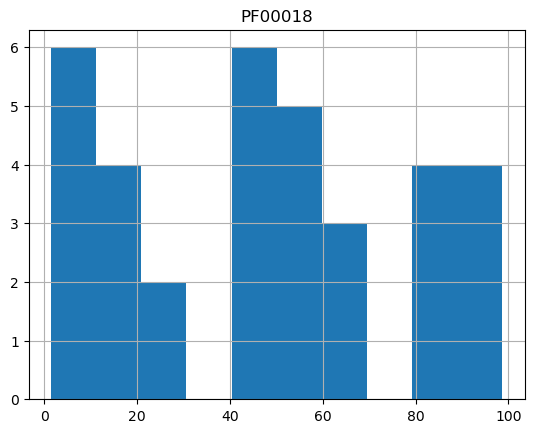

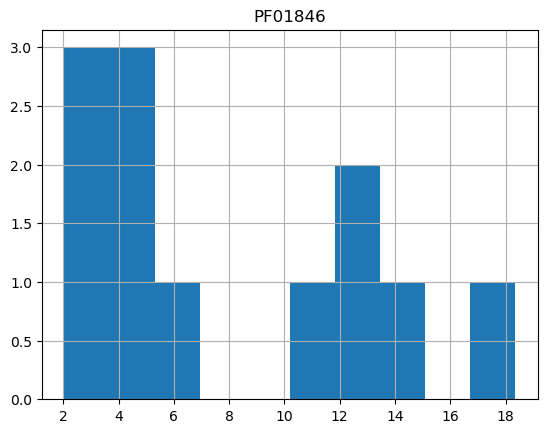

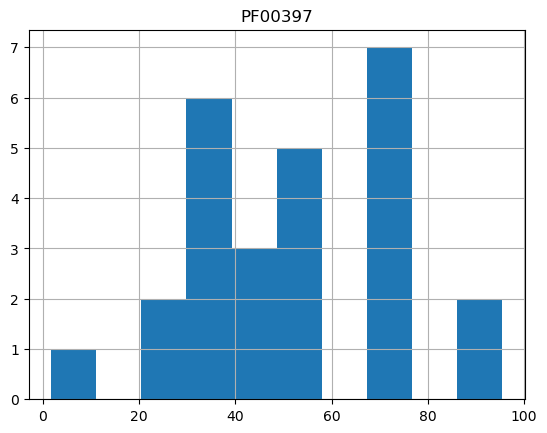

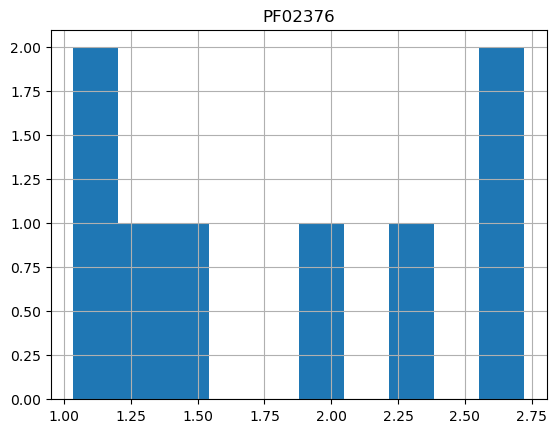

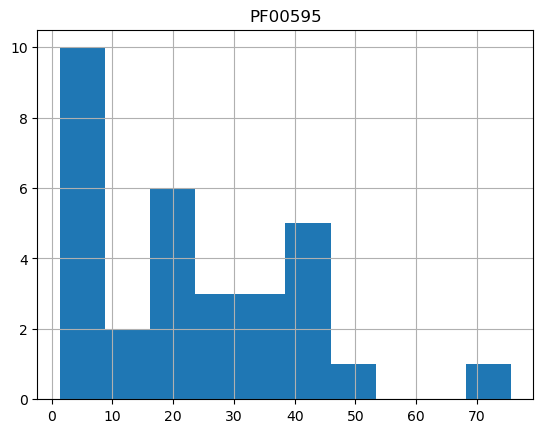

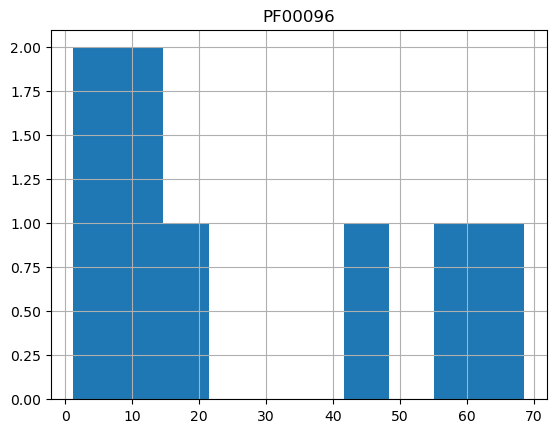

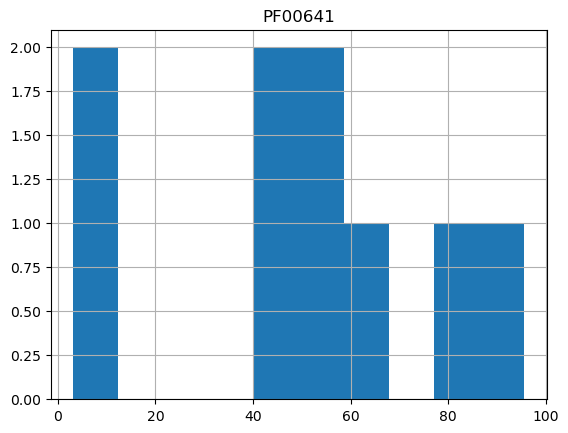

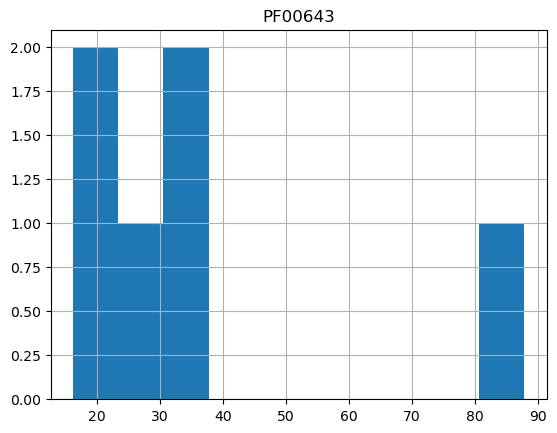

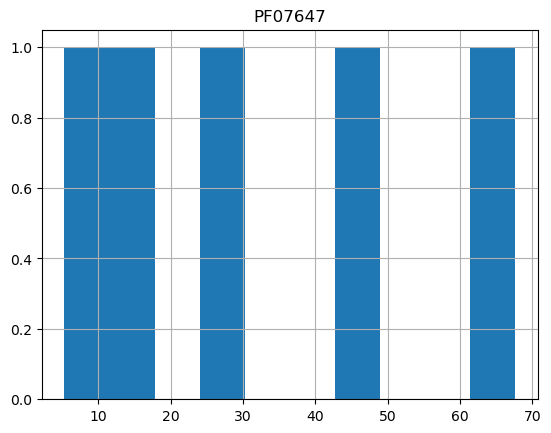

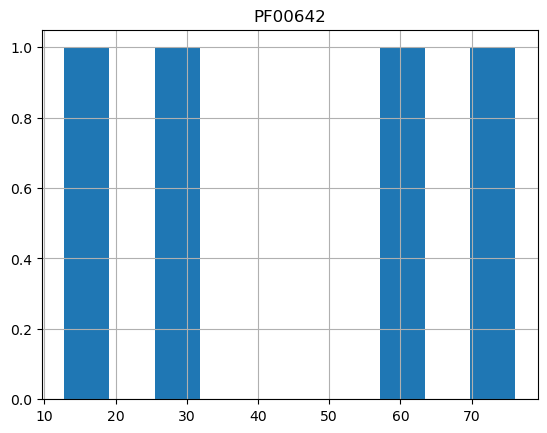

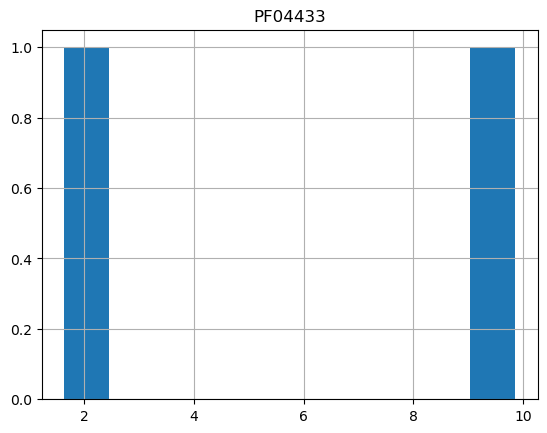

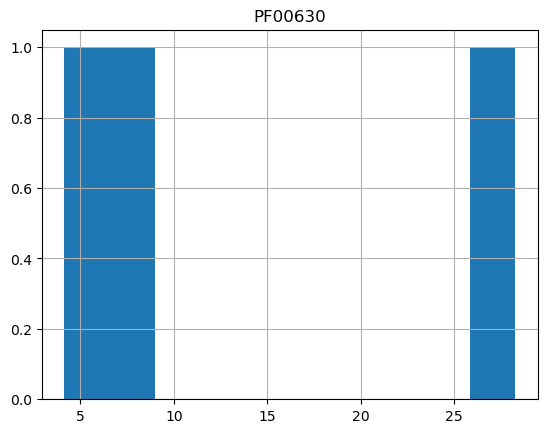

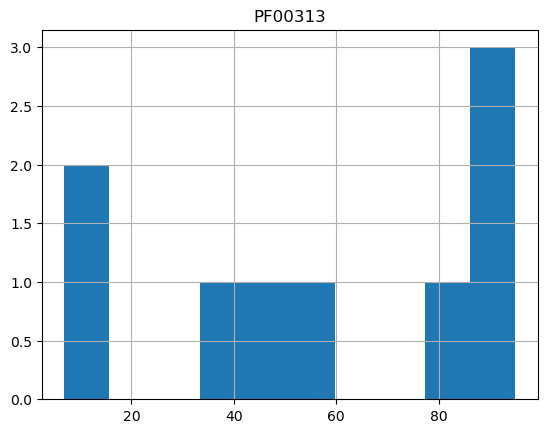

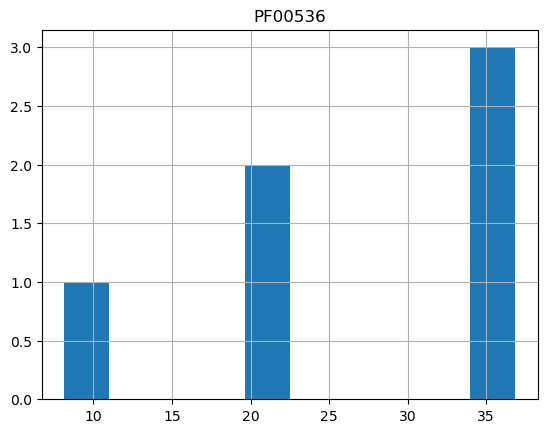

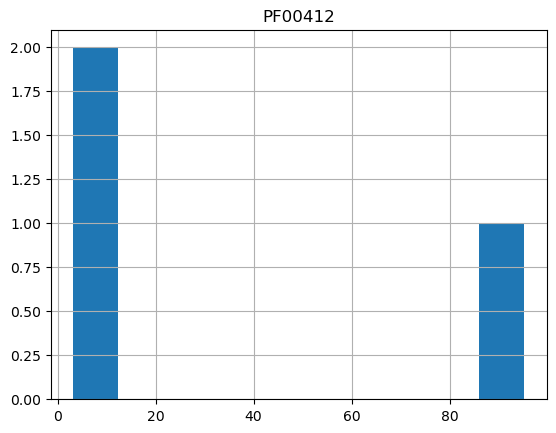

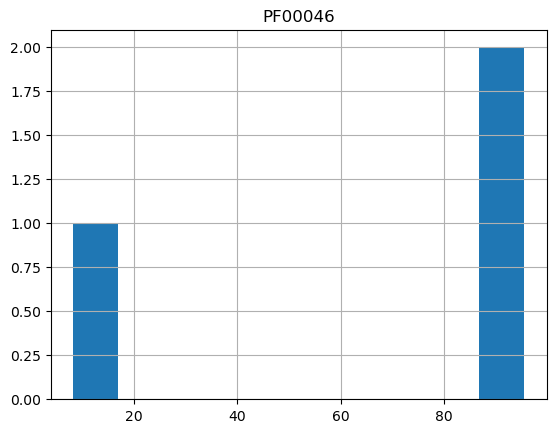

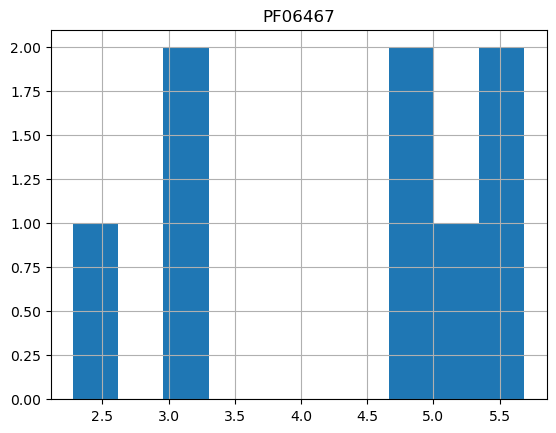

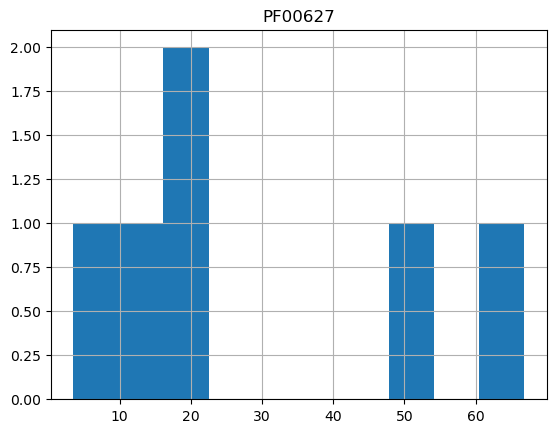

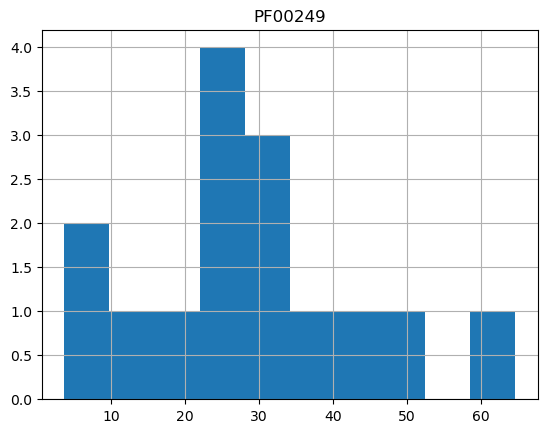

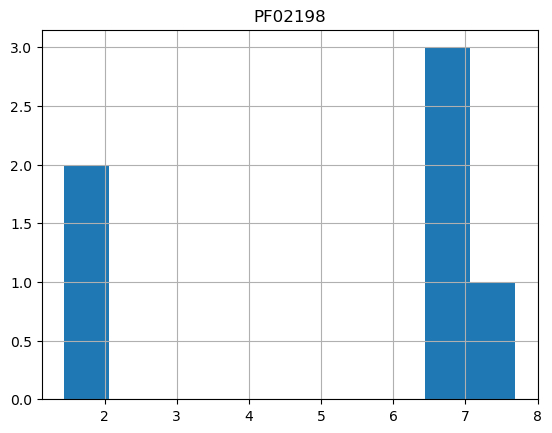

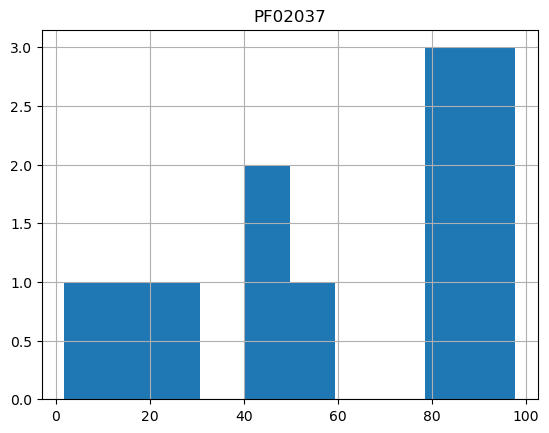

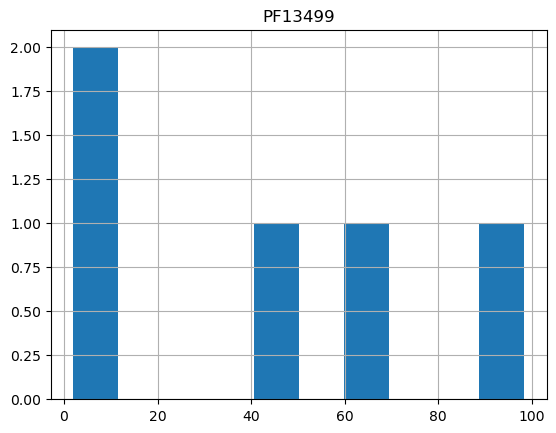

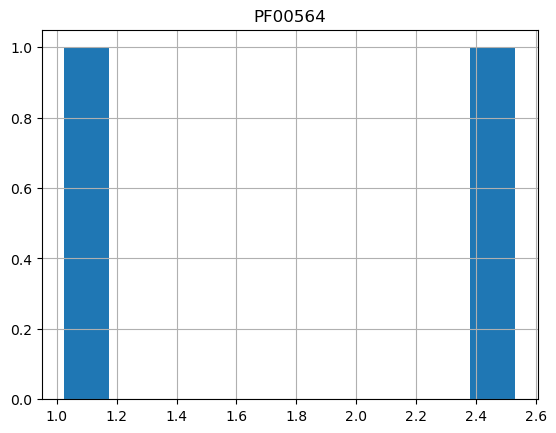

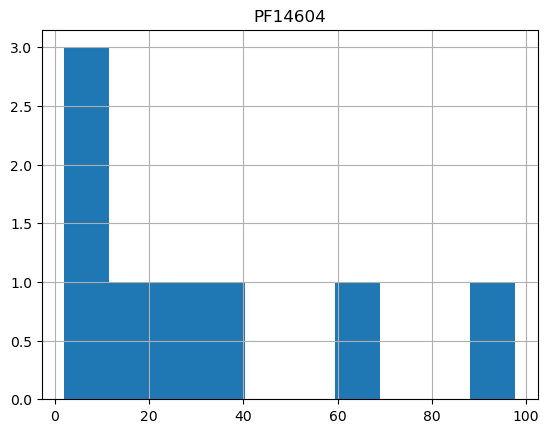

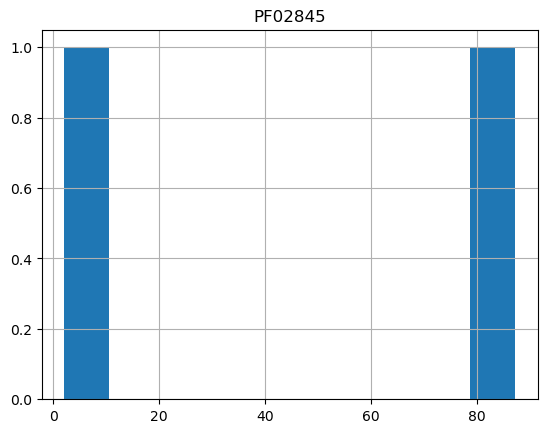

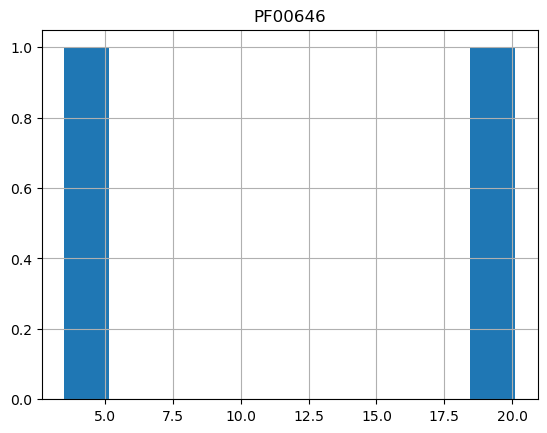

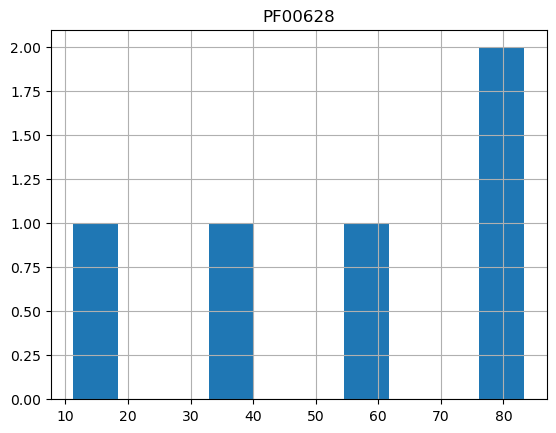

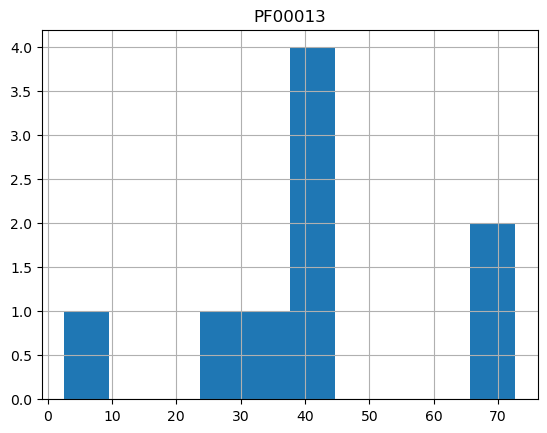

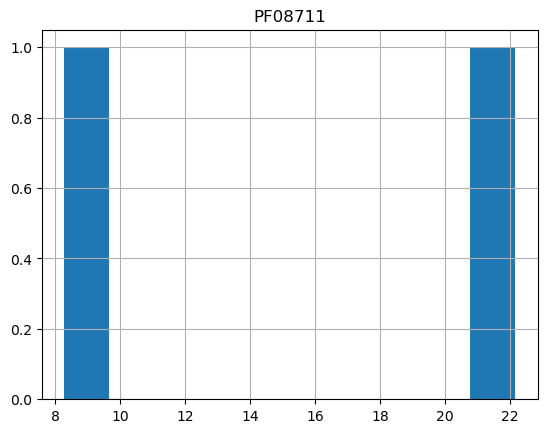

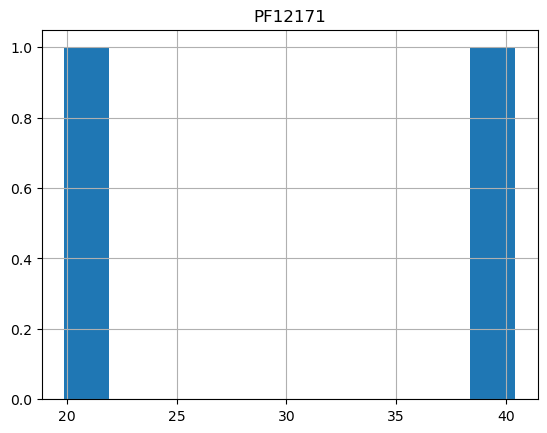

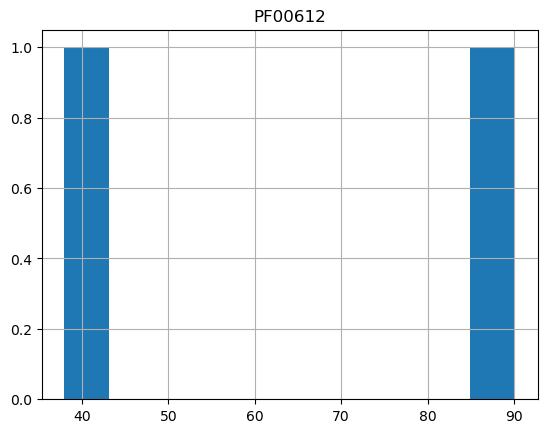

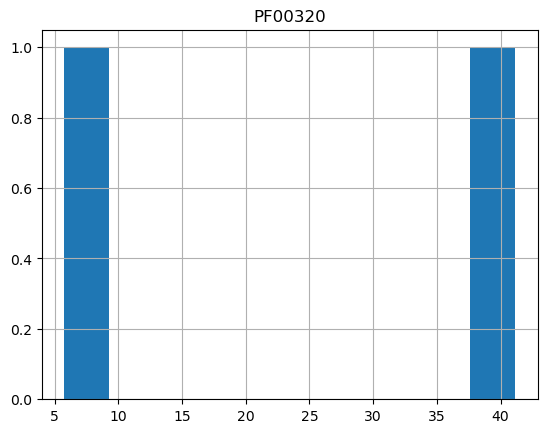

In [88]:
aln_stats_good_optimized_new['PFID'] = aln_stats_good_optimized_new['protein'].apply(lambda x: x.split('_')[1])
aln_stats_good_optimized_new['UniProt'] = aln_stats_good_optimized_new['protein'].apply(lambda x: x.split('_')[0])
for PFID in aln_stats_good_optimized_new['PFID'].unique():
    if (aln_stats_good_optimized_new[aln_stats_good_optimized_new['PFID'] == PFID]['n_eff_l'].max()-aln_stats_good_optimized_new[aln_stats_good_optimized_new['PFID'] == PFID]['n_eff_l'].min())/aln_stats_good_optimized_new[aln_stats_good_optimized_new['PFID'] == PFID]['n_eff_l'].min() > 1:
        aln_stats_good_optimized_new[aln_stats_good_optimized_new['PFID'] == PFID].hist('n_eff_l')
        plt.title(PFID)

In [99]:
aln_stats_rerun_higher_new

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
43,A0PJY2_PF00096_289,4082271,4087406,0.998744,4.082271e+06,185557.772727,22,21,0.954545,0.7
604,A0PJY2_PF00096_289,3092510,3096441,0.998730,3.092510e+06,140568.636364,22,21,0.954545,0.9
903,A0PJY2_PF00096_289,1738850,1740971,0.998782,1.875711e+04,852.595913,22,21,0.954545,1.2
62,O14813_PF00046_92,290088,290756,0.997703,6.198376e+03,110.685282,56,55,0.982143,0.7
68,O15266_PF00046_119,298587,299260,0.997751,6.293092e+03,112.376642,56,55,0.982143,0.7
...,...,...,...,...,...,...,...,...,...,...
603,Q9Y2G7_PF00096_411,3163997,3168306,0.998640,3.163997e+06,143818.045455,22,21,0.954545,0.9
936,Q9Y2G7_PF00096_411,1908998,1911479,0.998702,2.391964e+04,1087.256139,22,21,0.954545,1.2
550,Q9Y462_PF00096_506,4154305,4159285,0.998803,4.154305e+06,188832.045455,22,21,0.954545,0.7
635,Q9Y462_PF00096_506,3124430,3128293,0.998765,3.124430e+06,142019.545455,22,21,0.954545,0.9


In [41]:
def find_bitscore_for_higher_runs(df):
    best_row = df['bitscore'].idxmax()
    return df.loc[best_row]

# def generate_bitscore(bitscore, max_bitscore=2, bitscore_interval=0.1):
#     bitscore_list = []
#     while np.round(bitscore, 2) < max_bitscore:
#         bitscore += bitscore_interval
#         if bitscore < max_bitscore:
#             bitscore_list.append(np.round(bitscore, 2))
#     if len(bitscore_list) == 0:
#         bitscore_list = [1.1]
#     return bitscore_list

def generate_bitscore(bitscore, max_bitscore=2, bitscore_interval=0.1):
    bitscore_list = []
    while np.round(bitscore, 2) < max_bitscore:
        bitscore += bitscore_interval
        if bitscore < max_bitscore and len(bitscore_list) < 3: # cap it at two more runs per sample
            bitscore_list.append(np.round(bitscore, 2))
    if len(bitscore_list) == 0:
        print(bitscore)
    return bitscore_list

def suggest_higher_bitscore_run(df_full, df, max_bitscore=2, PF00096_max_bitscore=1.5):
    # find the highest bitscore
    df_highest_bitscore = df.groupby('protein').apply(find_bitscore_for_higher_runs)
    
    list_rerun = []
    for _, row in df_highest_bitscore.iterrows():
        if "_PF00096_" in row['protein']:
            list_rerun.append([row['protein'], PF00096_max_bitscore]) # to avoid spending too much time on PF00096
        else:
            bitscore_list = generate_bitscore(row['bitscore'])
            for bitscore in bitscore_list:
                list_rerun.append([row['protein'], bitscore])

    df_rerun = pd.DataFrame(list_rerun, columns=['protein', 'bitscore'])
    return df_rerun

In [148]:
higher_bitscore_run_df_new = suggest_higher_bitscore_run(full_df, aln_stats_rerun_higher_new)

/tmp/ipykernel_3290981/3718590525.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_highest_bitscore = df.groupby('protein').apply(find_bitscore_for_higher_runs)


In [149]:
higher_bitscore_run_df_new

,protein,bitscore
0,A0PJY2_PF00096_289,1.5
1,O14813_PF00046_92,0.8
2,O14813_PF00046_92,0.9
3,O14813_PF00046_92,1.0
4,O15266_PF00046_119,0.8
...,...,...
242,Q9UJQ4_PF00096_627,1.5
243,Q9UJQ4_PF00096_899,1.5
244,Q9UQR1_PF00096_172,1.5
245,Q9Y2G7_PF00096_411,1.5


In [150]:
higher_bitscore_run_df_new['protein'].nunique()

101

In [151]:
aln_stats_rerun_lower_new

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
20,EEHEE-rd3-0037_rockdoms_1,1,1,1.000000,1.000000,0.023256,43,43,1.000000,0.5
48,EEHEE-rd3-0037_rockdoms_1,1,1,1.000000,1.000000,0.023256,43,43,1.000000,0.7
5,P55895_PF13341_415,1295,1330,0.973684,15.692192,0.203795,77,77,1.000000,0.5
27,P55895_PF13341_415,1295,1330,0.973684,15.821530,0.205474,77,77,1.000000,0.6
253,P55895_PF13341_415,1295,1330,0.973684,15.847524,0.205812,77,77,1.000000,0.7
6,P61960_PF03671_4,1735,1747,0.993131,50.370649,0.680684,74,74,1.000000,0.5
28,P61960_PF03671_4,1734,1746,0.993127,48.892061,0.660704,74,74,1.000000,0.6
261,P61960_PF03671_4,1741,1753,0.993155,45.835868,0.619404,74,74,1.000000,0.7
9,Q01826_PF16557_178,3776,3783,0.998150,39.753770,0.567911,70,70,1.000000,0.5
31,Q01826_PF16557_178,3775,3782,0.998149,40.212104,0.574459,70,70,1.000000,0.6


Can keep these at the highest n_eff_l

In [16]:
def choose_best_bitscore_for_lower_runs(df):
    return df.groupby('protein').apply(find_bitscore)

# aln_stats_lower_optimized_new = choose_best_bitscore_for_lower_runs(aln_stats_rerun_lower_new)
# aln_stats_lower_optimized_new = aln_stats_lower_optimized_new[aln_stats_lower_optimized_new['protein'] != 'EEHEE-rd3-0037_rockdoms_1']
# aln_stats_lower_optimized_new

In [156]:
pd.concat([aln_stats_good_optimized_new, aln_stats_lower_optimized_new], ignore_index=True, axis=0).sort_values(by=['protein']).to_csv('output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_good_Jul10_aln_stats.csv', index=False)

Manually add back some reruns

In [144]:
manual_rerun_dict = {
    'protein': ['HHH-rd1-0142_rockdoms_1', 'O00330_PF02817_181', 'P02549_PF00018_979', 'Q6XZF7_PF00018_146'],
    'bitscore': [0.6, 0.95, 0.95, 0.95]
}
manual_rerun_df = pd.DataFrame.from_dict(manual_rerun_dict)

In [145]:
rerun_bitscore_new_df = pd.concat([higher_bitscore_run_df_new, manual_rerun_df])

In [64]:
bitscore_7_df = pd.read_csv('input/Beltran_Lehner_2025/sequences_0.7.csv')
def conv_list_to_csv(lst, output_path, full_csv_df=bitscore_7_df):
    protein_name_df = pd.DataFrame(lst, columns=['UniProt_ID'])
    protein_full_df = protein_name_df.merge(bitscore_7_df, how='inner', on='UniProt_ID')
    protein_full_df.to_csv(output_path, index=False)

def conv_list_to_csv_multi_bitscore(bitscore_rerun_df, output_prefix, output_suffix, full_csv_df=bitscore_7_df):
    bitscore_list = bitscore_rerun_df['bitscore'].unique().tolist()
    for bitscore in bitscore_list:
        bitscore_df = bitscore_rerun_df[bitscore_rerun_df['bitscore'] == bitscore]['protein'].tolist()
        # print(bitscore)
        # print(bitscore_df)
        conv_list_to_csv(bitscore_df, f"{output_prefix}_{bitscore}_{output_suffix}")

In [158]:
conv_list_to_csv_multi_bitscore(rerun_bitscore_new_df, 'input/Beltran_Lehner_2025/sequences', 'round4.csv')

In [159]:
rerun_bitscore_new_df['bitscore'].unique()

array([1.5 , 0.8 , 0.9 , 1.  , 1.2 , 1.3 , 1.4 , 0.6 , 0.95])

In [7]:
for f in glob('input/Beltran_Lehner_2025/sequences_*_round4.csv'):
    df = pd.read_csv(f)
    for _, row in df.iterrows():
        protein = row['UniProt_ID']
        m2a = f"output/Beltran_Lehner_2025/uniref100/{protein}/{protein}_bit_0.9_theta_0.8_colcov_0/align/{protein}_bit_0.9_theta_0.8_colcov_0.a2m"
        if not exists(m2a):
            print(protein)

HHH-rd1-0142_rockdoms_1


bailout failure: no sequences found

In [3]:
for f in glob('input/Beltran_Lehner_2025/sequences_*_round4.csv'):
    df = pd.read_csv(f)
    print(df.head())

                UniProt_ID                                   target_seq  \
0  HHH-rd1-0142_rockdoms_1  RKWEEIAERLREEFNINPEEAREAVEKAGGNEEEARRIVKKRL   

   MSA_region  MSA_theta  
0         NaN        0.2  
           UniProt_ID                                         target_seq  \
0   O14813_PF00046_92  RIRTTFTSAQLKELERVFAETHYPDIYTREELALKIDLTEARVQVW...   
1  O15266_PF00046_119  RSRTNFTLEQLNELERLFDETHYPDAFMREELSQRLGLSEARVQVW...   
2   O43186_PF00046_41  RERTTFTRSQLEELEALFAKTQYPDVYAREEVALKINLPESRVQVW...   
3   O75360_PF00046_71  RHRTTFSPVQLEQLESAFGRNQYPDIWARESLARDTGLSEARIQVW...   
4  O94929_PF00412_149  SHCAGCKEEIKHGQSLLALDKQWHVSCFKCQTCSVILTGEYISKDG...   

   MSA_region  MSA_theta  
0         NaN        0.2  
1         NaN        0.2  
2         NaN        0.2  
3         NaN        0.2  
4         NaN        0.2  
           UniProt_ID                                         target_seq  \
0  O00330_PF02817_181    RFRLSPAARNILEKHSLDASQGTATGPRGIFTKEDALKLVQLKQTGK   
1  P02549_PF00018_979  E

In [8]:
a2m_root_dir = './output/Beltran_Lehner_2025/'
for f in glob('input/Beltran_Lehner_2025/sequences_*_round4.csv'):
    df = pd.read_csv(f)
    bit = float(f.removeprefix("input/Beltran_Lehner_2025/sequences_").removesuffix("_round4.csv"))
    if bit == 1.0:
        a2m_dir = a2m_root_dir + f"bitscore1_a2m/"
    else:
        a2m_dir = a2m_root_dir + f"bitscore{bit}_a2m/"
    os.makedirs(a2m_dir, exist_ok=True)
    protein_list = df['UniProt_ID'].tolist()
    # generate the mapping .csv
    mapping_file = f"./output/Beltran_Lehner_2025/mappings/beltran_domains_jackhmmer_bitscore_{bit}_mapping_round4.csv"
    with open(mapping_file, 'w') as f_out:
        f_out.write('protein_name,msa_location,theta\n')    
        for protein in protein_list:
            src_a2m_file = f"./output/Beltran_Lehner_2025/uniref100/{protein}/{protein}_bit_{bit}_theta_0.8_colcov_0/align/{protein}_bit_{bit}_theta_0.8_colcov_0.a2m"

            if exists(src_a2m_file):
                # copy the .a2m files
                shutil.copy2(src_a2m_file, a2m_dir)
                # add entry to the mapping file
                protein_name = protein
                f_out.write(f"{protein},{basename(src_a2m_file)},0.2\n")

In [5]:
prefix = 'beltran_domains_jackhmmer_bitscore_'
full_df_list = []
for aln_stats_f in glob("./output/Beltran_Lehner_2025/aln_stats/*_bitscore_*_aln_stats.csv"):
    if os.path.getsize(aln_stats_f) > 1:
        df = pd.read_csv(aln_stats_f)
        bitscore = float(basename(aln_stats_f).removeprefix(prefix).split("_")[0])
        df['bitscore'] = bitscore
        full_df_list.append(df)
full_df = pd.concat(full_df_list, ignore_index=True, axis=0).sort_values(by=['protein', 'bitscore'])

In [6]:
full_df

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
43,A0A2R8Y422_PF00240_2,61139,61559,0.993177,5.929080e+03,84.701140,70,68,0.971429,0.7
44,A0PJY2_PF00096_289,4082271,4087406,0.998744,4.082271e+06,185557.772727,22,21,0.954545,0.7
666,A0PJY2_PF00096_289,3092510,3096441,0.998730,3.092510e+06,140568.636364,22,21,0.954545,0.9
1025,A0PJY2_PF00096_289,1738850,1740971,0.998782,1.875711e+04,852.595913,22,21,0.954545,1.2
1119,A0PJY2_PF00096_289,645261,645870,0.999057,1.813469e+03,82.430408,22,21,0.954545,1.5
...,...,...,...,...,...,...,...,...,...,...
839,Q9Y5K6_PF14604_109,263559,263728,0.999359,6.539988e+03,107.212910,61,53,0.868852,0.9
1023,Q9Y5K6_PF14604_109,101884,101933,0.999519,1.764578e+03,28.927503,61,53,0.868852,1.1
557,Q9Y618_PF00249_613,57496,57518,0.999618,1.467850e+03,25.307762,58,48,0.827586,0.7
558,Q9Y6N9_PF00595_207,123241,123337,0.999222,1.477510e+03,16.601235,89,74,0.831461,0.7


In [10]:
aln_stats_good_new = full_df.groupby('protein').filter(good_run_condition_new)
aln_stats_rerun_higher_new = full_df.groupby('protein').filter(rerun_higher_bitscore_condition_new)
aln_stats_rerun_lower_new = full_df.groupby('protein').filter(rerun_lower_bitscore_condition_new)

In [11]:
print(aln_stats_good_new['protein'].nunique())
print(aln_stats_rerun_higher_new['protein'].nunique())
print(aln_stats_rerun_lower_new['protein'].nunique())
full_protein_set = set(full_df['protein'].tolist())
good_protein_set = set(aln_stats_good_new['protein'].tolist())
rerun_higher_protein_set = set(aln_stats_rerun_higher_new['protein'].tolist())
rerun_lower_protein_set = set(aln_stats_rerun_lower_new['protein'].tolist())
assert good_protein_set & rerun_higher_protein_set == set()
assert good_protein_set & rerun_lower_protein_set == set()
assert rerun_higher_protein_set & rerun_lower_protein_set == set()
full_df[full_df['protein'].isin(list(full_protein_set - (good_protein_set | rerun_higher_protein_set | rerun_lower_protein_set)))]

509
1
6


,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
21,HHH-rd1-0142_rockdoms_1,95906,96071,0.998283,5.839246e+03,135.796420,43,35,0.813953,0.50
42,HHH-rd1-0142_rockdoms_1,1,1,1.000000,1.000000e+00,0.023256,43,43,1.000000,0.60
51,HHH-rd1-0142_rockdoms_1,1,1,1.000000,1.000000e+00,0.023256,43,43,1.000000,0.70
53,O00330_PF02817_181,174292,174577,0.998367,1.784180e+04,379.612695,47,38,0.808511,0.70
740,O00330_PF02817_181,123402,123553,0.998778,1.131278e+04,240.697524,47,37,0.787234,0.90
658,O00330_PF02817_181,65729,65802,0.998891,6.818908e+03,145.083151,47,38,0.808511,0.95
898,O00330_PF02817_181,1448,1448,1.000000,3.883908e+01,0.826363,47,43,0.914894,1.05
924,O00330_PF02817_181,1414,1415,0.999293,1.802737e+01,0.383561,47,45,0.957447,1.10
490,Q9H9D4_PF00096_383,4215680,4220675,0.998817,4.215680e+06,200746.666667,21,21,1.000000,0.70
685,Q9H9D4_PF00096_383,3344761,3348831,0.998785,3.344761e+06,159274.333333,21,21,1.000000,0.90


Manually select these - other than `HHH-rd1-0142_rockdoms_1` bitscore = 0.5, others select the rows with Neff/L < 100

In [15]:
def find_bitscore_min(df):
    best_row = df['n_eff_l'].idxmin()
    return df.loc[best_row]

def choose_best_bitscore_for_higher_runs(df, max_num_seq=2000000, min_perc_cov=0.7):
    df = df[(df['num_seqs'] < max_num_seq) & (np.round(df['perc_cov'], 2) >= min_perc_cov)]
    return df.groupby('protein').apply(find_bitscore_min)

In [22]:
def choose_best_bitscore_for_other(df, max_num_seq=2000000, min_perc_cov=0.7, max_neff_l=100):
    df = df[(df['num_seqs'] < max_num_seq) & (np.round(df['perc_cov'], 2) >= min_perc_cov) & (df['n_eff_l'] <= max_n_eff_l)]
    return df.groupby('protein').apply(find_bitscore)

In [24]:
other_df = full_df[full_df['protein'].isin(list(full_protein_set - (good_protein_set | rerun_higher_protein_set | rerun_lower_protein_set)))]
other_df_optimized = choose_best_bitscore_for_other(other_df)

/tmp/ipykernel_903226/4042392041.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('protein').apply(find_bitscore)


In [14]:
aln_stats_good_optimized_new = choose_best_bitscore(aln_stats_good_new)
aln_stats_good_optimized_new

/tmp/ipykernel_903226/1098527250.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('protein').apply(find_bitscore)


,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
protein,,,,,,,,,,
A0A2R8Y422_PF00240_2,A0A2R8Y422_PF00240_2,61139,61559,0.993177,5929.079783,84.701140,70,68,0.971429,0.7
A0PJY2_PF00096_289,A0PJY2_PF00096_289,645261,645870,0.999057,1813.468976,82.430408,22,21,0.954545,1.5
A1X283_PF00018_155,A1X283_PF00018_155,33185,33216,0.999067,721.882034,13.125128,55,52,0.945455,0.9
A1X283_PF00018_222,A1X283_PF00018_222,45557,45592,0.999232,947.707467,16.062838,59,53,0.898305,0.9
A2RRE5_PF01846_267,A2RRE5_PF01846_267,4527,4543,0.996478,128.704577,2.042930,63,60,0.952381,0.7
...,...,...,...,...,...,...,...,...,...,...
Q9Y5K6_PF14604_1,Q9Y5K6_PF14604_1,91124,91191,0.999265,1947.714465,33.012110,59,52,0.881356,1.1
Q9Y5K6_PF14604_109,Q9Y5K6_PF14604_109,101884,101933,0.999519,1764.577706,28.927503,61,53,0.868852,1.1
Q9Y618_PF00249_613,Q9Y618_PF00249_613,57496,57518,0.999618,1467.850172,25.307762,58,48,0.827586,0.7


In [17]:
aln_stats_lower_optimized_new = choose_best_bitscore_for_lower_runs(aln_stats_rerun_lower_new)
aln_stats_lower_optimized_new = aln_stats_lower_optimized_new[aln_stats_lower_optimized_new['protein'] != 'EEHEE-rd3-0037_rockdoms_1']
aln_stats_lower_optimized_new

/tmp/ipykernel_903226/1106140195.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('protein').apply(find_bitscore)


,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
protein,,,,,,,,,,
P55895_PF13341_415,P55895_PF13341_415,1295,1330,0.973684,15.847524,0.205812,77,77,1.000000,0.7
P61960_PF03671_4,P61960_PF03671_4,1735,1747,0.993131,50.370649,0.680684,74,74,1.000000,0.5
Q01826_PF16557_178,Q01826_PF16557_178,3775,3782,0.998149,40.253770,0.575054,70,70,1.000000,0.7
Q13163_PF00564_15,Q13163_PF00564_15,1971,1971,1.000000,44.319275,0.466519,95,94,0.989474,0.5
Q9UL15_PF02179_280,Q9UL15_PF02179_280,1189,1194,0.995812,21.401262,0.310163,69,69,1.000000,0.6


In [18]:
aln_stats_rerun_higher_new

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
131,P02417_PF01281_1,50851,50985,0.997372,6121.095594,130.236076,47,44,0.936170,0.7
606,P02417_PF01281_1,50459,50593,0.997351,5983.963624,127.318375,47,44,0.936170,0.8
846,P02417_PF01281_1,49972,50104,0.997365,6197.043370,131.851987,47,45,0.957447,0.9
1221,P02417_PF01281_1,49393,49524,0.997355,6050.058412,128.724647,47,45,0.957447,1.0
1024,P02417_PF01281_1,47793,47921,0.997329,5839.139832,124.237018,47,45,0.957447,1.1
1075,P02417_PF01281_1,46904,47022,0.997491,5592.447193,118.988238,47,45,0.957447,1.2
1091,P02417_PF01281_1,45488,45590,0.997763,5241.198038,111.514852,47,45,0.957447,1.3


In [19]:
aln_stats_higher_optimized_new = choose_best_bitscore_for_higher_runs(aln_stats_rerun_higher_new)
aln_stats_higher_optimized_new

/tmp/ipykernel_903226/8521946.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('protein').apply(find_bitscore_min)


1091,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
protein,,,,,,,,,,
P02417_PF01281_1,P02417_PF01281_1,45488,45590,0.997763,5241.198038,111.514852,47,45,0.957447,1.3


In [20]:
full_df[full_df['protein'].isin(['EHEE-rd1-0882_rockdoms_1', 'HHH-rd1-0142_rockdoms_1'])]

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
0,EHEE-rd1-0882_rockdoms_1,461951,462120,0.999634,109295.701468,2732.392537,40,30,0.750000,0.5
22,EHEE-rd1-0882_rockdoms_1,582,582,1.000000,166.602763,4.165069,40,28,0.700000,0.6
50,EHEE-rd1-0882_rockdoms_1,8,8,1.000000,6.000000,0.150000,40,30,0.750000,0.7
21,HHH-rd1-0142_rockdoms_1,95906,96071,0.998283,5839.246049,135.796420,43,35,0.813953,0.5
42,HHH-rd1-0142_rockdoms_1,1,1,1.000000,1.000000,0.023256,43,43,1.000000,0.6
51,HHH-rd1-0142_rockdoms_1,1,1,1.000000,1.000000,0.023256,43,43,1.000000,0.7


In [21]:
design_df = pd.concat([
    full_df[(full_df['protein'] == 'EHEE-rd1-0882_rockdoms_1') & (full_df['bitscore'] == 0.6)],
    full_df[(full_df['protein'] == 'HHH-rd1-0142_rockdoms_1') & (full_df['bitscore'] == 0.5)]
])

In [25]:
final_df = pd.concat([
    aln_stats_good_optimized_new, 
    aln_stats_lower_optimized_new, 
    aln_stats_higher_optimized_new, 
    other_df_optimized[other_df_optimized['protein']!='HHH-rd1-0142_rockdoms_1'], 
    design_df
    ], 
    ignore_index=True, axis=0).sort_values(by=['protein'])

In [26]:
final_df['protein'].nunique()

521

In [35]:
full_df[full_df['protein'].isin(list(full_protein_set - set(final_df['protein'].tolist())))]

,protein,num_seqs,num_seqs_unfiltered,perc_filtered,n_eff,n_eff_l,seq_len,num_cov,perc_cov,bitscore
20,EEHEE-rd3-0037_rockdoms_1,1,1,1.0,1.0,0.023256,43,43,1.0,0.5
49,EEHEE-rd3-0037_rockdoms_1,1,1,1.0,1.0,0.023256,43,43,1.0,0.7


In [27]:
final_df.to_csv('output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_5round_Jul21_aln_stats.csv', index=False)

## Summary of round 4
- Only one design protein `EEHEE-rd3-0037_rockdoms_1` is excluded due to low number of sequences
- Can further increase bitscores within `aln_stats_rerun_higher_new`
- Can find an intermediate bitscores for `other_df`

In [11]:
final_df = pd.read_csv('output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_5round_Jul21_aln_stats.csv')
# file_df = download_weights_move_msa(final_df, idmapping_dict)
file_df.to_csv("output/Beltran_Lehner_2025/beltran_domains_jackhmmer_5round_Jul21_file.csv", index=False)

In [12]:
# final_df = pd.read_csv('output/Beltran_Lehner_2025/aln_stats/beltran_domains_jackhmmer_5round_Jul21_aln_stats.csv')
# file_df = download_weights_move_msa(final_df, idmapping_dict)
file_df = pd.read_csv("output/Beltran_Lehner_2025/beltran_domains_jackhmmer_5round_Jul21_file.csv")

In [43]:
target_seq_df = pd.read_csv('output/Beltran_Lehner_2025/target_seq.csv')
merged_df = merge_file_final_df(file_df, final_df, target_seq_df)
MSA_df = add_MSA_0_colcov_info(merged_df, idmapping_dict)
MSA_df['MSA_theta'] = 0.2
MSA_df['taxon'] = 'Human'
MSA_df['source_organism'] = 'Saccharomyces cerevisiae'
MSA_df['includes_multiple_mutants'] = 'FALSE'
MSA_df['DMS_wildtype_score'] = 0
MSA_df['first_author'] = 'Beltran'
MSA_df['coarse_selection_type'] = 'Abundance'
MSA_df.to_csv("output/Beltran_Lehner_2025/temp_ref_file.csv", index=False)

## Round 5

In [43]:
def suggest_higher_bitscore_run(df_full, df, max_bitscore=2):
    # find the highest bitscore
    df_highest_bitscore = df.groupby('protein').apply(find_bitscore_for_higher_runs)
    
    list_rerun = []
    for _, row in df_highest_bitscore.iterrows():
        bitscore_list = generate_bitscore(row['bitscore'])
        for bitscore in bitscore_list:
            list_rerun.append([row['protein'], bitscore])

    df_rerun = pd.DataFrame(list_rerun, columns=['protein', 'bitscore'])
    return df_rerun

In [48]:
round5_bitscore_higher_df = suggest_higher_bitscore_run(full_df, aln_stats_rerun_higher_new, 2)

/tmp/ipykernel_1579671/2137925948.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_highest_bitscore = df.groupby('protein').apply(find_bitscore_for_higher_runs)


In [60]:
round5_bitscore_other_list = [["O00330_PF02817_181", 1], ["O00330_PF02817_181", 1.05]]
for protein in other_df['protein'].unique().tolist():
    if protein != 'HHH-rd1-0142_rockdoms_1' and protein != "O00330_PF02817_181":
        round5_bitscore_other_list.extend([[protein, 1.3], [protein, 1.4]])
round5_bitscore_other_df = pd.DataFrame(round5_bitscore_other_list, columns=['protein', 'bitscore'])

In [62]:
round_5_bitscore_df = pd.concat([round5_bitscore_higher_df, round5_bitscore_other_df],
                                ignore_index=True, axis=0).sort_values(by=['protein'])
round_5_bitscore_df

,protein,bitscore
48,O00330_PF02817_181,1.00
49,O00330_PF02817_181,1.05
0,O43167_PF00096_435,1.60
1,O43167_PF00096_435,1.70
2,O43167_PF00096_435,1.80
...,...,...
43,Q9Y2G7_PF00096_411,1.70
42,Q9Y2G7_PF00096_411,1.60
45,Q9Y462_PF00096_506,1.60
46,Q9Y462_PF00096_506,1.70


In [63]:
conv_list_to_csv_multi_bitscore(round_5_bitscore_df, 'input/Beltran_Lehner_2025/sequences', 'round5.csv')

1.0
['O00330_PF02817_181']
1.05
['O00330_PF02817_181']
1.6
['O43167_PF00096_435', 'O75953_PF00226_4', 'P25685_PF00226_4', 'P37275_PF00096_933', 'P51508_PF00096_331', 'P51508_PF00096_555', 'P57071_PF00096_1085', 'Q5VTD9_PF00096_221', 'Q99684_PF00096_313', 'Q9H3Z4_PF00226_16', 'Q9HC78_PF00096_635', 'Q9NU63_PF00096_176', 'Q9UBS4_PF00226_25', 'Q9Y2G7_PF00096_411', 'Q9Y462_PF00096_506']
1.7
['O43167_PF00096_435', 'O75953_PF00226_4', 'P25685_PF00226_4', 'P37275_PF00096_933', 'P51508_PF00096_331', 'P51508_PF00096_555', 'P57071_PF00096_1085', 'Q5VTD9_PF00096_221', 'Q99684_PF00096_313', 'Q9H3Z4_PF00226_16', 'Q9HC78_PF00096_635', 'Q9NU63_PF00096_176', 'Q9UBS4_PF00226_25', 'Q9Y2G7_PF00096_411', 'Q9Y462_PF00096_506']
1.8
['O43167_PF00096_435', 'P37275_PF00096_933', 'P51508_PF00096_331', 'P51508_PF00096_555', 'P57071_PF00096_1085', 'Q5VTD9_PF00096_221', 'Q99684_PF00096_313', 'Q9HC78_PF00096_635', 'Q9NU63_PF00096_176', 'Q9Y2G7_PF00096_411', 'Q9Y462_PF00096_506']
1.5
['O75953_PF00226_4', 'P25685_PF00

In [54]:
round_5_bitscore_df['bitscore'].unique()

array([1.  , 1.05, 1.6 , 1.7 , 1.8 , 1.5 , 1.1 , 1.2 , 1.3 , 1.4 ])

In [3]:
a2m_root_dir = './output/Beltran_Lehner_2025/'
for f in glob('input/Beltran_Lehner_2025/sequences_*_round5.csv'):
    df = pd.read_csv(f)
    bit = float(f.removeprefix("input/Beltran_Lehner_2025/sequences_").removesuffix("_round5.csv"))
    if bit == 1.0:
        a2m_dir = a2m_root_dir + f"bitscore1_a2m/"
    else:
        a2m_dir = a2m_root_dir + f"bitscore{bit}_a2m/"
    os.makedirs(a2m_dir, exist_ok=True)
    protein_list = df['UniProt_ID'].tolist()
    # generate the mapping .csv
    mapping_file = f"./output/Beltran_Lehner_2025/mappings/beltran_domains_jackhmmer_bitscore_{bit}_mapping_round5.csv"
    with open(mapping_file, 'w') as f_out:
        f_out.write('protein_name,msa_location,theta\n')    
        for protein in protein_list:
            src_a2m_file = f"./output/Beltran_Lehner_2025/uniref100/{protein}/{protein}_bit_{bit}_theta_0.8_colcov_0/align/{protein}_bit_{bit}_theta_0.8_colcov_0.a2m"

            if exists(src_a2m_file):
                # copy the .a2m files
                shutil.copy2(src_a2m_file, a2m_dir)
                # add entry to the mapping file
                protein_name = protein
                f_out.write(f"{protein},{basename(src_a2m_file)},0.2\n")
            else:
                print(protein, bit)

Rerun the code above from round 4 and update the output file names